In [1]:
from pathlib import Path
#import pandas as pd

from pyMut import read_maf
from pyMut import read_vcf
from pyMut.core import PyMutation, MutationMetadata
from pyMut.annotate.vep_annotate import wrap_maf_vep_annotate_protein

PyMutation.configure_high_quality_plots()

WORKING_DIR = Path("/home/albalopez/Documentos/PyMut_DocsAlba/")

# Configuración global
cohort_name = "TCGA_PAAD_DefValidation"
results_dir_name = f"results_{cohort_name.lower()}_pymut"
RESULTS_DIR = WORKING_DIR / results_dir_name
RESULTS_DIR.mkdir(parents=True, exist_ok=True)


In [2]:

# Archivos de entrada 
maf_path = WORKING_DIR / "data/PAAD-TB.final_analysis.maf" #tcga_laml.maf.gz #PAAD-TB.final_analysis.maf #tcga_laml_VEP_annotated.maf.gz
#vcf_path = WORKING_DIR / "data/your_file.vcf"

ref_genome = WORKING_DIR / "data/references/hs37d5.fa"
ref_genome_38 = WORKING_DIR / "data/references/Homo_sapiens.GRCh38.dna.primary_assembly.fa"
# cosmic_path = WORKING_DIR / "data/references/COSMIC_v3.4_SBS_GRCh37.txt"
cosmic_path_maftools = WORKING_DIR / "data/references/maftools_SBS_catalog.tsv"
aetiology_path = WORKING_DIR / "data/references/maftools_SBS_aetiology.tsv"

def out(filename: str) -> Path:
    return RESULTS_DIR / f"{cohort_name.lower()}_{filename}"


def cohort_title(text: str) -> str:
    return f"{text} - {cohort_name.replace('_', '-')}"



In [3]:

mutations = read_maf(
    maf_path,
    assembly="37",
    consolidate_variants=True
)
print(mutations.data.shape)
print(mutations.data.head())


2026-09-23 16:32:47,179 | INFO | pyMut.input | Starting MAF reading: /home/albalopez/Documentos/PyMut_DocsAlba/data/PAAD-TB.final_analysis.maf
2026-09-23 16:32:47,182 | INFO | pyMut.input | Loading from cache: /home/albalopez/Documentos/PyMut_DocsAlba/data/.pymut_cache/PAAD-TB.final_analysis_171b2ae545db2d47.parquet
2026-09-23 16:32:47,999 | INFO | pyMut.input | Cache loaded successfully in 0.82 seconds


(37619, 564)
   CHROM        POS         ID REF ALT QUAL FILTER  \
0  chr22   41650338  139571477   G   A    .      .   
1   chr1  118550780          .   G   A    .      .   
2  chr19   44739673          .   A   T    .      .   
3  chr17   67016614   61740908   C   T    .      .   
4  chr21   37783861  370336150   C   T    .      .   

  TCGA-2J-AAB1-01A-11D-A40W-08 TCGA-2J-AAB4-01A-12D-A40W-08  \
0                          G|A                          G|G   
1                          G|A                          G|G   
2                          A|T                          A|A   
3                          C|T                          C|C   
4                          C|T                          C|C   

  TCGA-2J-AAB6-01A-11D-A40W-08  ... is_missense is_nonsense is_splice  \
0                          G|G  ...           1           0         0   
1                          G|G  ...           1           0         0   
2                          A|A  ...           1           0     

In [4]:
# from pyMut.annotate.vep_annotate import wrap_maf_vep_annotate_protein

# success, info = wrap_maf_vep_annotate_protein(
#     maf_file=maf_path,                    # the .maf or .maf.gz file
#     cache_dir="/path/to/your/homo_sapiens_vep_114_GRCh37",     # where you extracted the cache
#     fasta=ref_genome,
#     #assembly="GRCh37", version="114",          # optional: auto-extracted from the cache folder name
#     #output_file="tcga_paad.vep.maf.gz",
#     compress=True,                                 # the merged MAF is output as .gz
#     no_stats=True,                                 # faster, skips the HTML statistics report
# )

# print(success)
# print(info)

In [5]:
# mutations = read_vcf(
#      vcf_path,
#      assembly="38",
#  )
# print(mutations.data.shape)
# print(mutations.data.head())

In [6]:
# from pyMut.annotate.vep_annotate import wrap_vcf_vep_annotate_unified

# vcf_success, vcf_info = wrap_vcf_vep_annotate_unified(
#     vcf_file=vcf_path,
#     fasta=ref_genome_38,
#     cache_dir="/run/media/albalopez/CC5A1D695A1D5196/Alba_Fedora/PyMut/homo_sapiens_vep_114_GRCh38",
#     annotate_protein=True,        # --protein --uniprot --domains --symbol
#     annotate_gene=False,          # --symbol (+ --nearest/--distance si se pasa distance)
#     annotate_variant_class=True, # --variant_class
#     no_stats=True,
# )

# print(vcf_success)
# print(vcf_info)

In [7]:
data = mutations.data
data.head()

,CHROM,POS,ID,REF,ALT,QUAL,FILTER,TCGA-2J-AAB1-01A-11D-A40W-08,TCGA-2J-AAB4-01A-12D-A40W-08,TCGA-2J-AAB6-01A-11D-A40W-08,...,is_missense,is_nonsense,is_splice,is_silent,context_orig,context65,categ,categ_ignoring_null_categ,gene_idx,pat_idx
0,chr22,41650338,139571477,G,A,.,.,G|A,G|G,G|G,...,1,0,0,0,519,40,1,1,12986,1
1,chr1,118550780,.,G,A,.,.,G|A,G|G,G|G,...,1,0,0,0,493,38,1,1,14931,1
2,chr19,44739673,.,A,T,.,.,A|T,A|A,A|A,...,1,0,0,0,39,3,4,4,17726,1
3,chr17,67016614,61740908,C,T,.,.,C|T,C|C,C|C,...,1,0,0,0,247,19,1,1,39,1
4,chr21,37783861,370336150,C,T,.,.,C|T,C|C,C|C,...,0,0,0,1,246,19,1,1,3300,1


In [8]:
tmb_results = mutations.calculate_tmb_analysis(
    variant_classification_column="Variant_Classification",
    genome_size_bp=50_000_000,
    output_dir=RESULTS_DIR,
    save_files=True
)


2026-09-23 16:33:09,318 | INFO | pyMut.analysis.mutation_burden | TMB analysis saved to: /home/albalopez/Documentos/PyMut_DocsAlba/results_tcga_paad_defvalidation_pymut/TMB_analysis.tsv
2026-09-23 16:33:09,318 | INFO | pyMut.analysis.mutation_burden | TMB statistics saved to: /home/albalopez/Documentos/PyMut_DocsAlba/results_tcga_paad_defvalidation_pymut/TMB_statistics.tsv
2026-09-23 16:33:09,319 | INFO | pyMut.analysis.mutation_burden | Analyzed 184 samples with 37619 total mutations
2026-09-23 16:33:09,319 | INFO | pyMut.analysis.mutation_burden | TMB ANALYSIS SUMMARY
2026-09-23 16:33:09,320 | INFO | pyMut.analysis.mutation_burden | • Total samples analyzed: 184
2026-09-23 16:33:09,321 | INFO | pyMut.analysis.mutation_burden | • Average non-synonymous mutations per sample: 187.9
2026-09-23 16:33:09,321 | INFO | pyMut.analysis.mutation_burden | • Average TMB: 3.757500 mutations/Mb
2026-09-23 16:33:09,322 | INFO | pyMut.analysis.mutation_burden | • Median TMB: 1.940000 mutations/Mb
202

In [9]:

analysis_df = tmb_results["analysis"]
statistics_df = tmb_results["statistics"]
analysis_df.to_csv(out("tmb_analysis.csv"), index=False)
statistics_df.to_csv(out("tmb_statistics.csv"), index=False)

In [10]:
tcga_cohort_label = cohort_name.replace("TCGA_", "") + "-EX"
tcga_compare_results = mutations.calculate_tcga_compare(
cohort_name=tcga_cohort_label,
capture_size=50, # Mb, same as genome_size_bp=50_000_000 used in calculate_tmb_analysis
output_dir=RESULTS_DIR,
save_files=True,
)
tcga_compare_results["median_mutation_burden"].head(10)

2026-09-23 16:33:09,766 | INFO | pyMut.analysis.mutation_burden | Auto-detected variant classification column: Variant_Classification
2026-09-23 16:33:31,184 | INFO | pyMut.analysis.mutation_burden | TMB ANALYSIS SUMMARY
2026-09-23 16:33:31,185 | INFO | pyMut.analysis.mutation_burden | • Total samples analyzed: 184
2026-09-23 16:33:31,185 | INFO | pyMut.analysis.mutation_burden | • Average non-synonymous mutations per sample: 187.9
2026-09-23 16:33:31,186 | INFO | pyMut.analysis.mutation_burden | • Average TMB: 3.757500 mutations/Mb
2026-09-23 16:33:31,187 | INFO | pyMut.analysis.mutation_burden | • Median TMB: 1.940000 mutations/Mb
2026-09-23 16:33:31,188 | INFO | pyMut.analysis.mutation_burden | • Sample with highest TMB: TCGA-IB-7651-01A-11D-2154-08
2026-09-23 16:33:31,189 | INFO | pyMut.analysis.mutation_burden |   - TMB value: 298.840000 mutations/Mb
2026-09-23 16:33:31,189 | INFO | pyMut.analysis.mutation_burden | • Sample with lowest TMB: TCGA-IB-AAUV-01A-11D-A38G-08
2026-09-23 

,Cohort,Cohort_Size,Median_Mutations
0,PCPG,183,0.251397
1,LAML,137,0.251397
2,THCA,499,0.279330
3,UVM,80,0.321229
4,TGCT,133,0.363128
5,THYM,123,0.391061
6,KICH,66,0.544693
7,ACC,92,0.712291
8,PRAD,495,0.754190
9,MESO,82,0.754190


2026-09-23 16:33:31,354 | INFO | pyMut.analysis.mutation_burden | Auto-detected variant classification column: Variant_Classification
2026-09-23 16:33:52,751 | INFO | pyMut.analysis.mutation_burden | TMB ANALYSIS SUMMARY
2026-09-23 16:33:52,751 | INFO | pyMut.analysis.mutation_burden | • Total samples analyzed: 184
2026-09-23 16:33:52,752 | INFO | pyMut.analysis.mutation_burden | • Average non-synonymous mutations per sample: 187.9
2026-09-23 16:33:52,752 | INFO | pyMut.analysis.mutation_burden | • Average TMB: 3.757500 mutations/Mb
2026-09-23 16:33:52,753 | INFO | pyMut.analysis.mutation_burden | • Median TMB: 1.940000 mutations/Mb
2026-09-23 16:33:52,754 | INFO | pyMut.analysis.mutation_burden | • Sample with highest TMB: TCGA-IB-7651-01A-11D-2154-08
2026-09-23 16:33:52,755 | INFO | pyMut.analysis.mutation_burden |   - TMB value: 298.840000 mutations/Mb
2026-09-23 16:33:52,755 | INFO | pyMut.analysis.mutation_burden | • Sample with lowest TMB: TCGA-IB-AAUV-01A-11D-A38G-08
2026-09-23 

📁 Figure saved: /home/albalopez/Documentos/PyMut_DocsAlba/results_tcga_paad_defvalidation_pymut/tcga_paad_defvalidation_tcga_compare.png (DPI: 300, margins: tight)


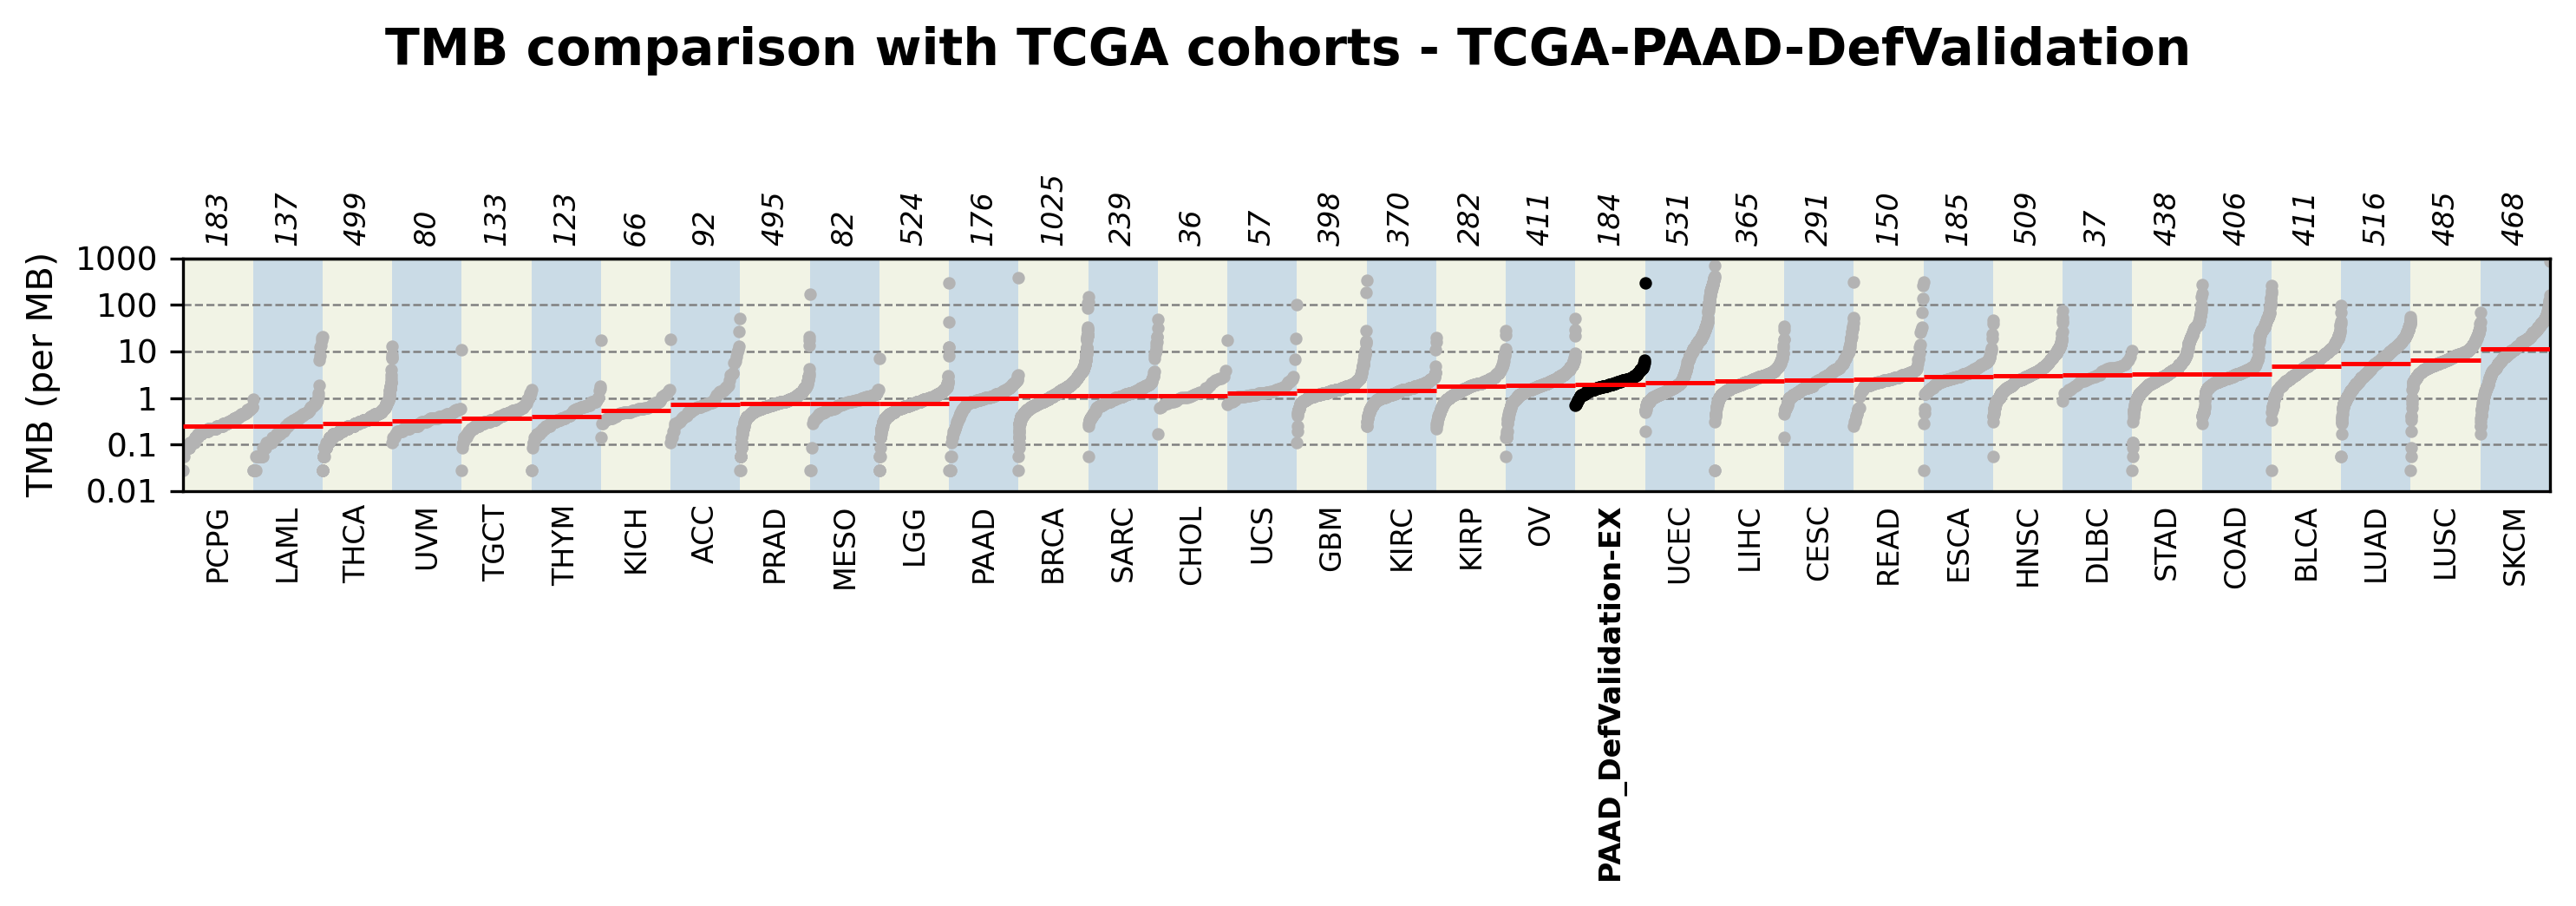

In [11]:
tcga_compare_fig = mutations.tcga_compare(
cohort_name=tcga_cohort_label,
capture_size=50,
logscale=True,
figsize=(10, 3.5),
title=cohort_title("TMB comparison with TCGA cohorts"),
)
mutations.save_figure(tcga_compare_fig, out("tcga_compare.png"))
tcga_compare_fig

In [12]:
samples = mutations.data.columns[mutations.data.columns.str.startswith("TCGA")].tolist()
print(samples)
len(samples)

['TCGA-2J-AAB1-01A-11D-A40W-08', 'TCGA-2J-AAB4-01A-12D-A40W-08', 'TCGA-2J-AAB6-01A-11D-A40W-08', 'TCGA-2J-AAB8-01A-12D-A40W-08', 'TCGA-2J-AAB9-01A-11D-A40W-08', 'TCGA-2J-AABA-01A-21D-A40W-08', 'TCGA-2J-AABE-01A-12D-A40W-08', 'TCGA-2J-AABF-01A-31D-A40W-08', 'TCGA-2J-AABH-01A-21D-A40W-08', 'TCGA-2J-AABI-01A-12D-A40W-08', 'TCGA-2J-AABK-01A-31D-A40W-08', 'TCGA-2J-AABO-01A-21D-A40W-08', 'TCGA-2J-AABP-01A-11D-A40W-08', 'TCGA-2J-AABR-01A-11D-A40W-08', 'TCGA-2J-AABT-01A-11D-A40W-08', 'TCGA-2J-AABU-01A-11D-A40W-08', 'TCGA-2J-AABV-01A-12D-A40W-08', 'TCGA-2L-AAQA-01A-21D-A38G-08', 'TCGA-2L-AAQE-01A-11D-A397-08', 'TCGA-2L-AAQI-01A-12D-A397-08', 'TCGA-2L-AAQJ-01A-12D-A397-08', 'TCGA-2L-AAQL-01A-11D-A38G-08', 'TCGA-2L-AAQM-01A-11D-A397-08', 'TCGA-3A-A9I5-01A-11D-A38G-08', 'TCGA-3A-A9I7-01A-21D-A38G-08', 'TCGA-3A-A9I9-01A-11D-A38G-08', 'TCGA-3A-A9IB-01A-21D-A397-08', 'TCGA-3A-A9IC-01A-11D-A38G-08', 'TCGA-3A-A9IH-01A-12D-A397-08', 'TCGA-3A-A9IJ-01A-11D-A397-08', 'TCGA-3A-A9IL-01A-11D-A38G-08', 'TCGA-3

186

2026-09-23 16:33:54,655 | INFO | pyMut.core | Generating summary plot...
2026-09-23 16:34:02,307 | INFO | pyMut.core | Summary plot generated in 7.65 seconds


📁 Figure saved: /home/albalopez/Documentos/PyMut_DocsAlba/results_tcga_paad_defvalidation_pymut/tcga_paad_defvalidation_summary.png (DPI: 300, margins: tight)


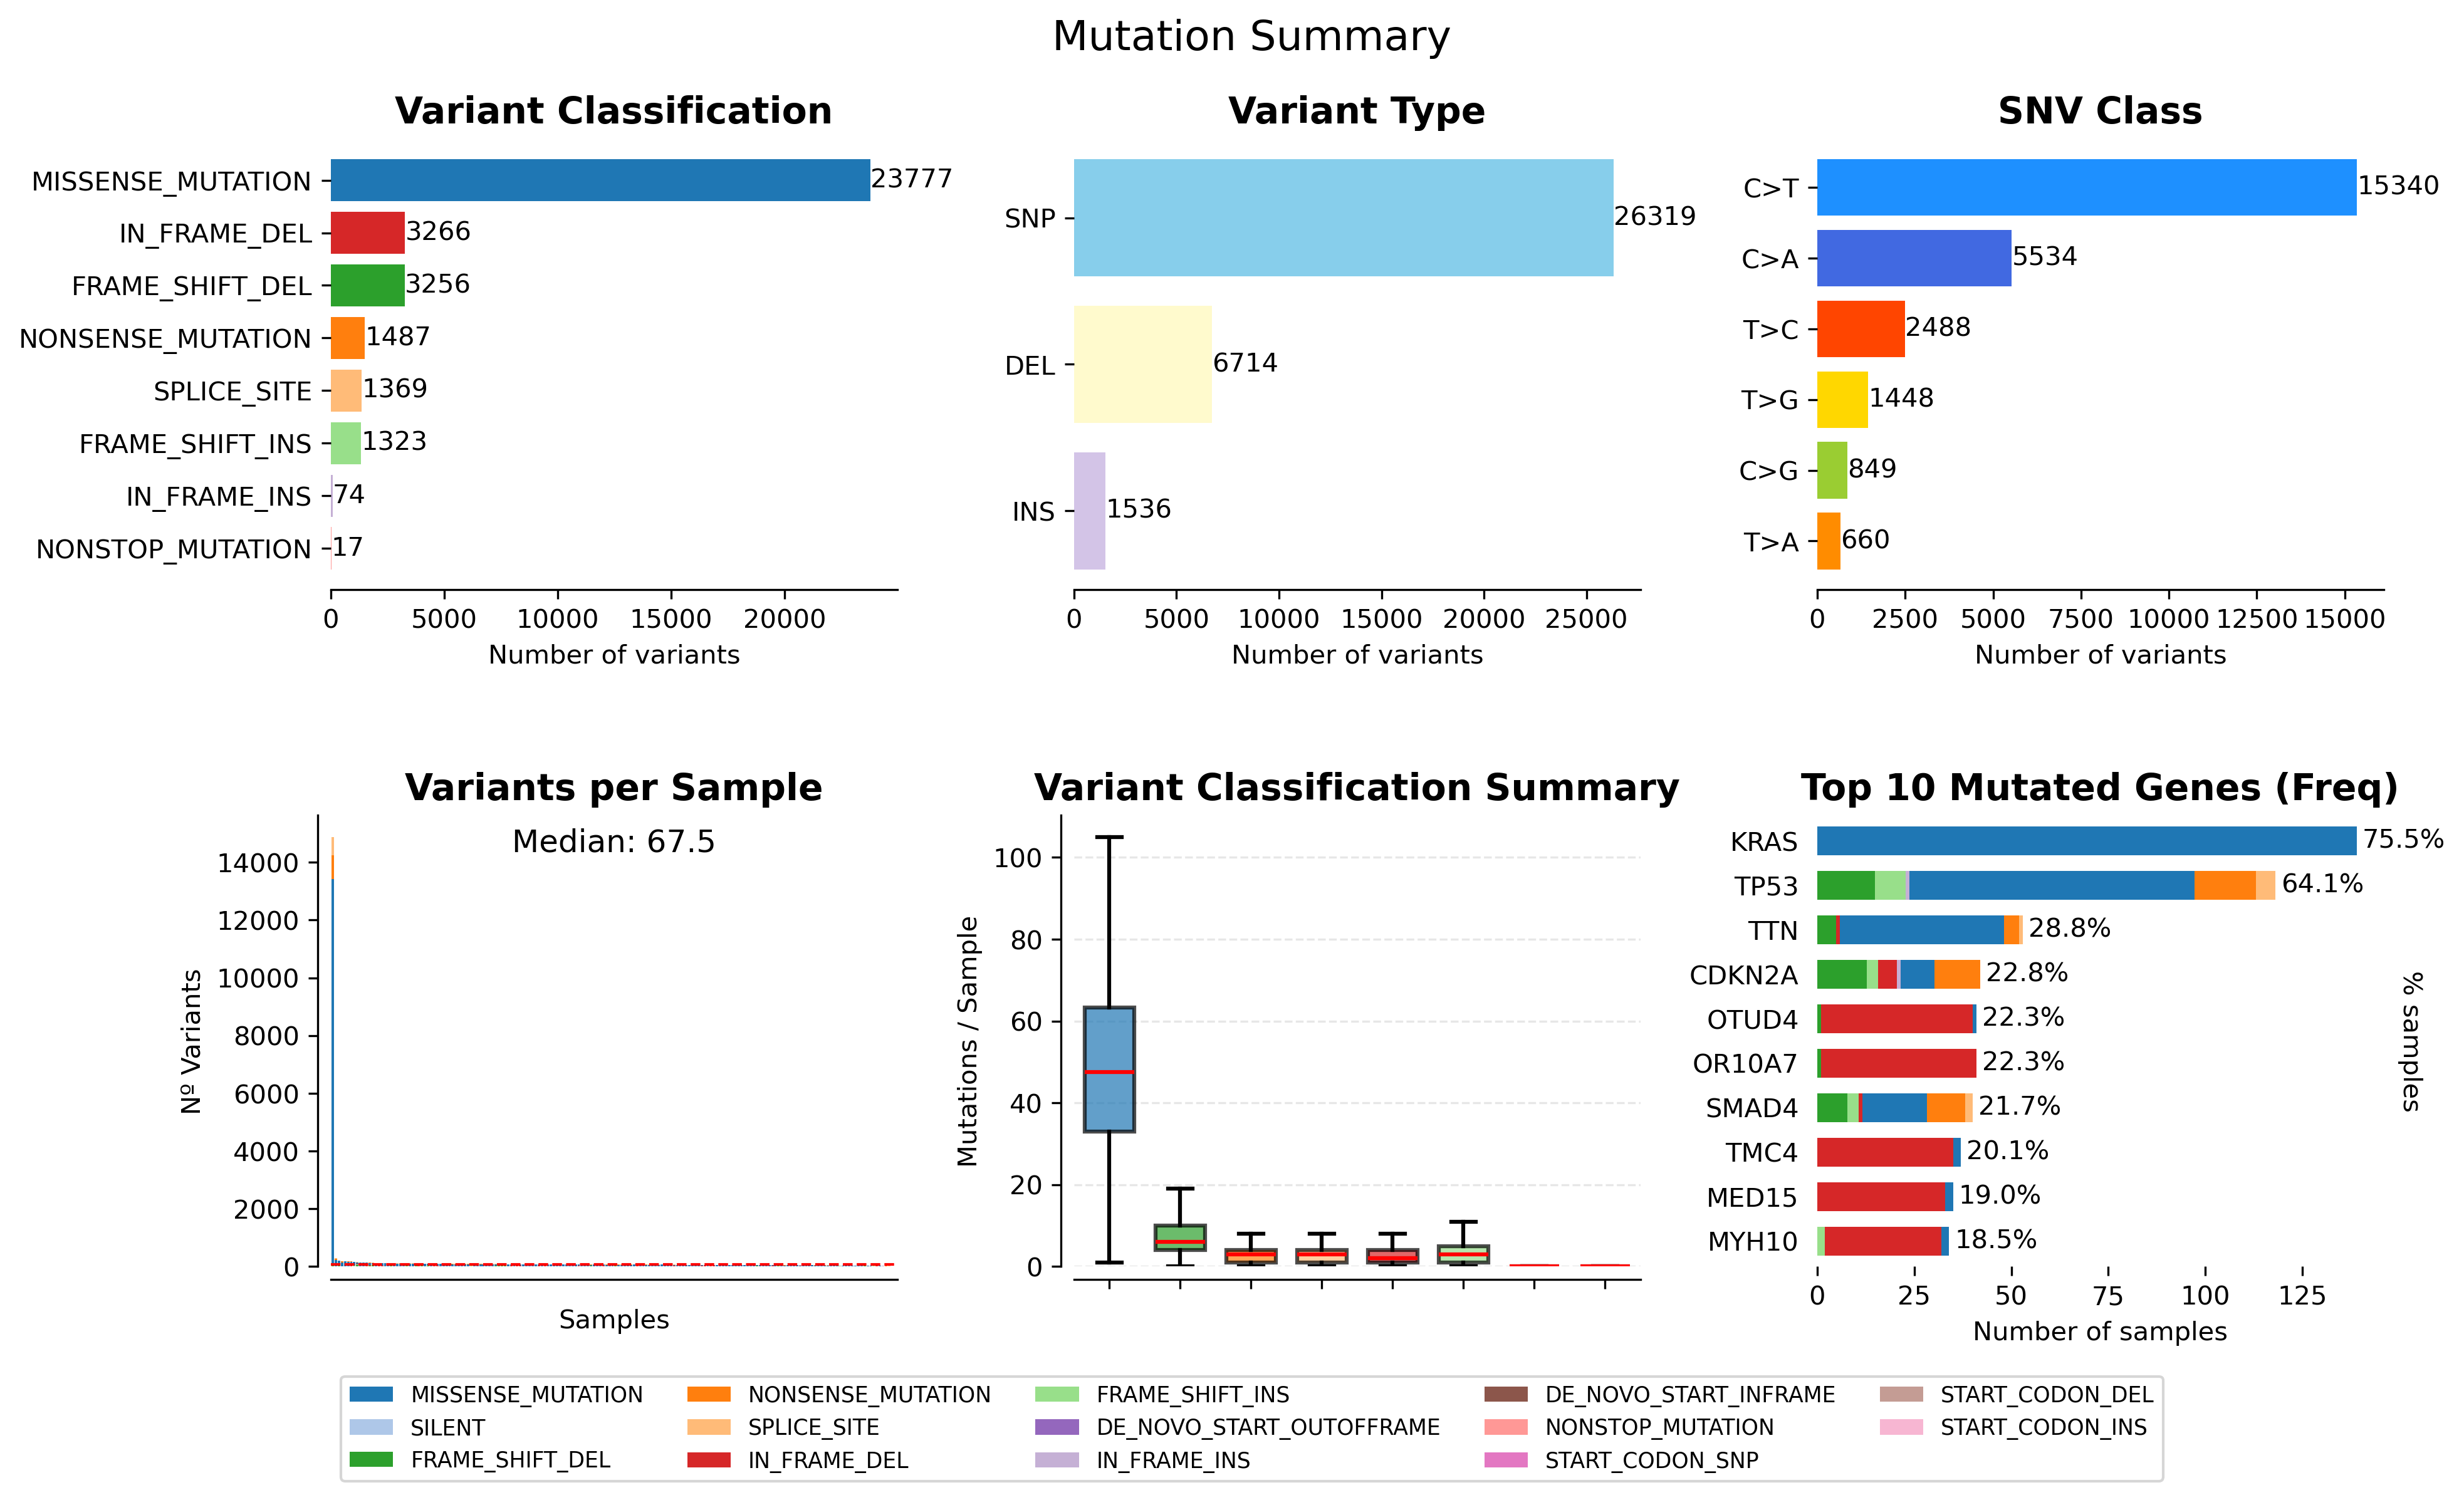

In [13]:
summary_fig = mutations.summary_plot(include_silent=False)
mutations.save_figure(summary_fig, out("summary.png"))
summary_fig

2026-09-23 16:34:05,433 | INFO | pyMut.core | Generating top mutated genes plot (mode=samples, count=10)...
2026-09-23 16:34:07,120 | INFO | pyMut.core | Top mutated genes plot generated in 1.69 seconds


📁 Figure saved: /home/albalopez/Documentos/PyMut_DocsAlba/results_tcga_paad_defvalidation_pymut/tcga_paad_defvalidation_top_mutated_genes.png (DPI: 300, margins: tight)


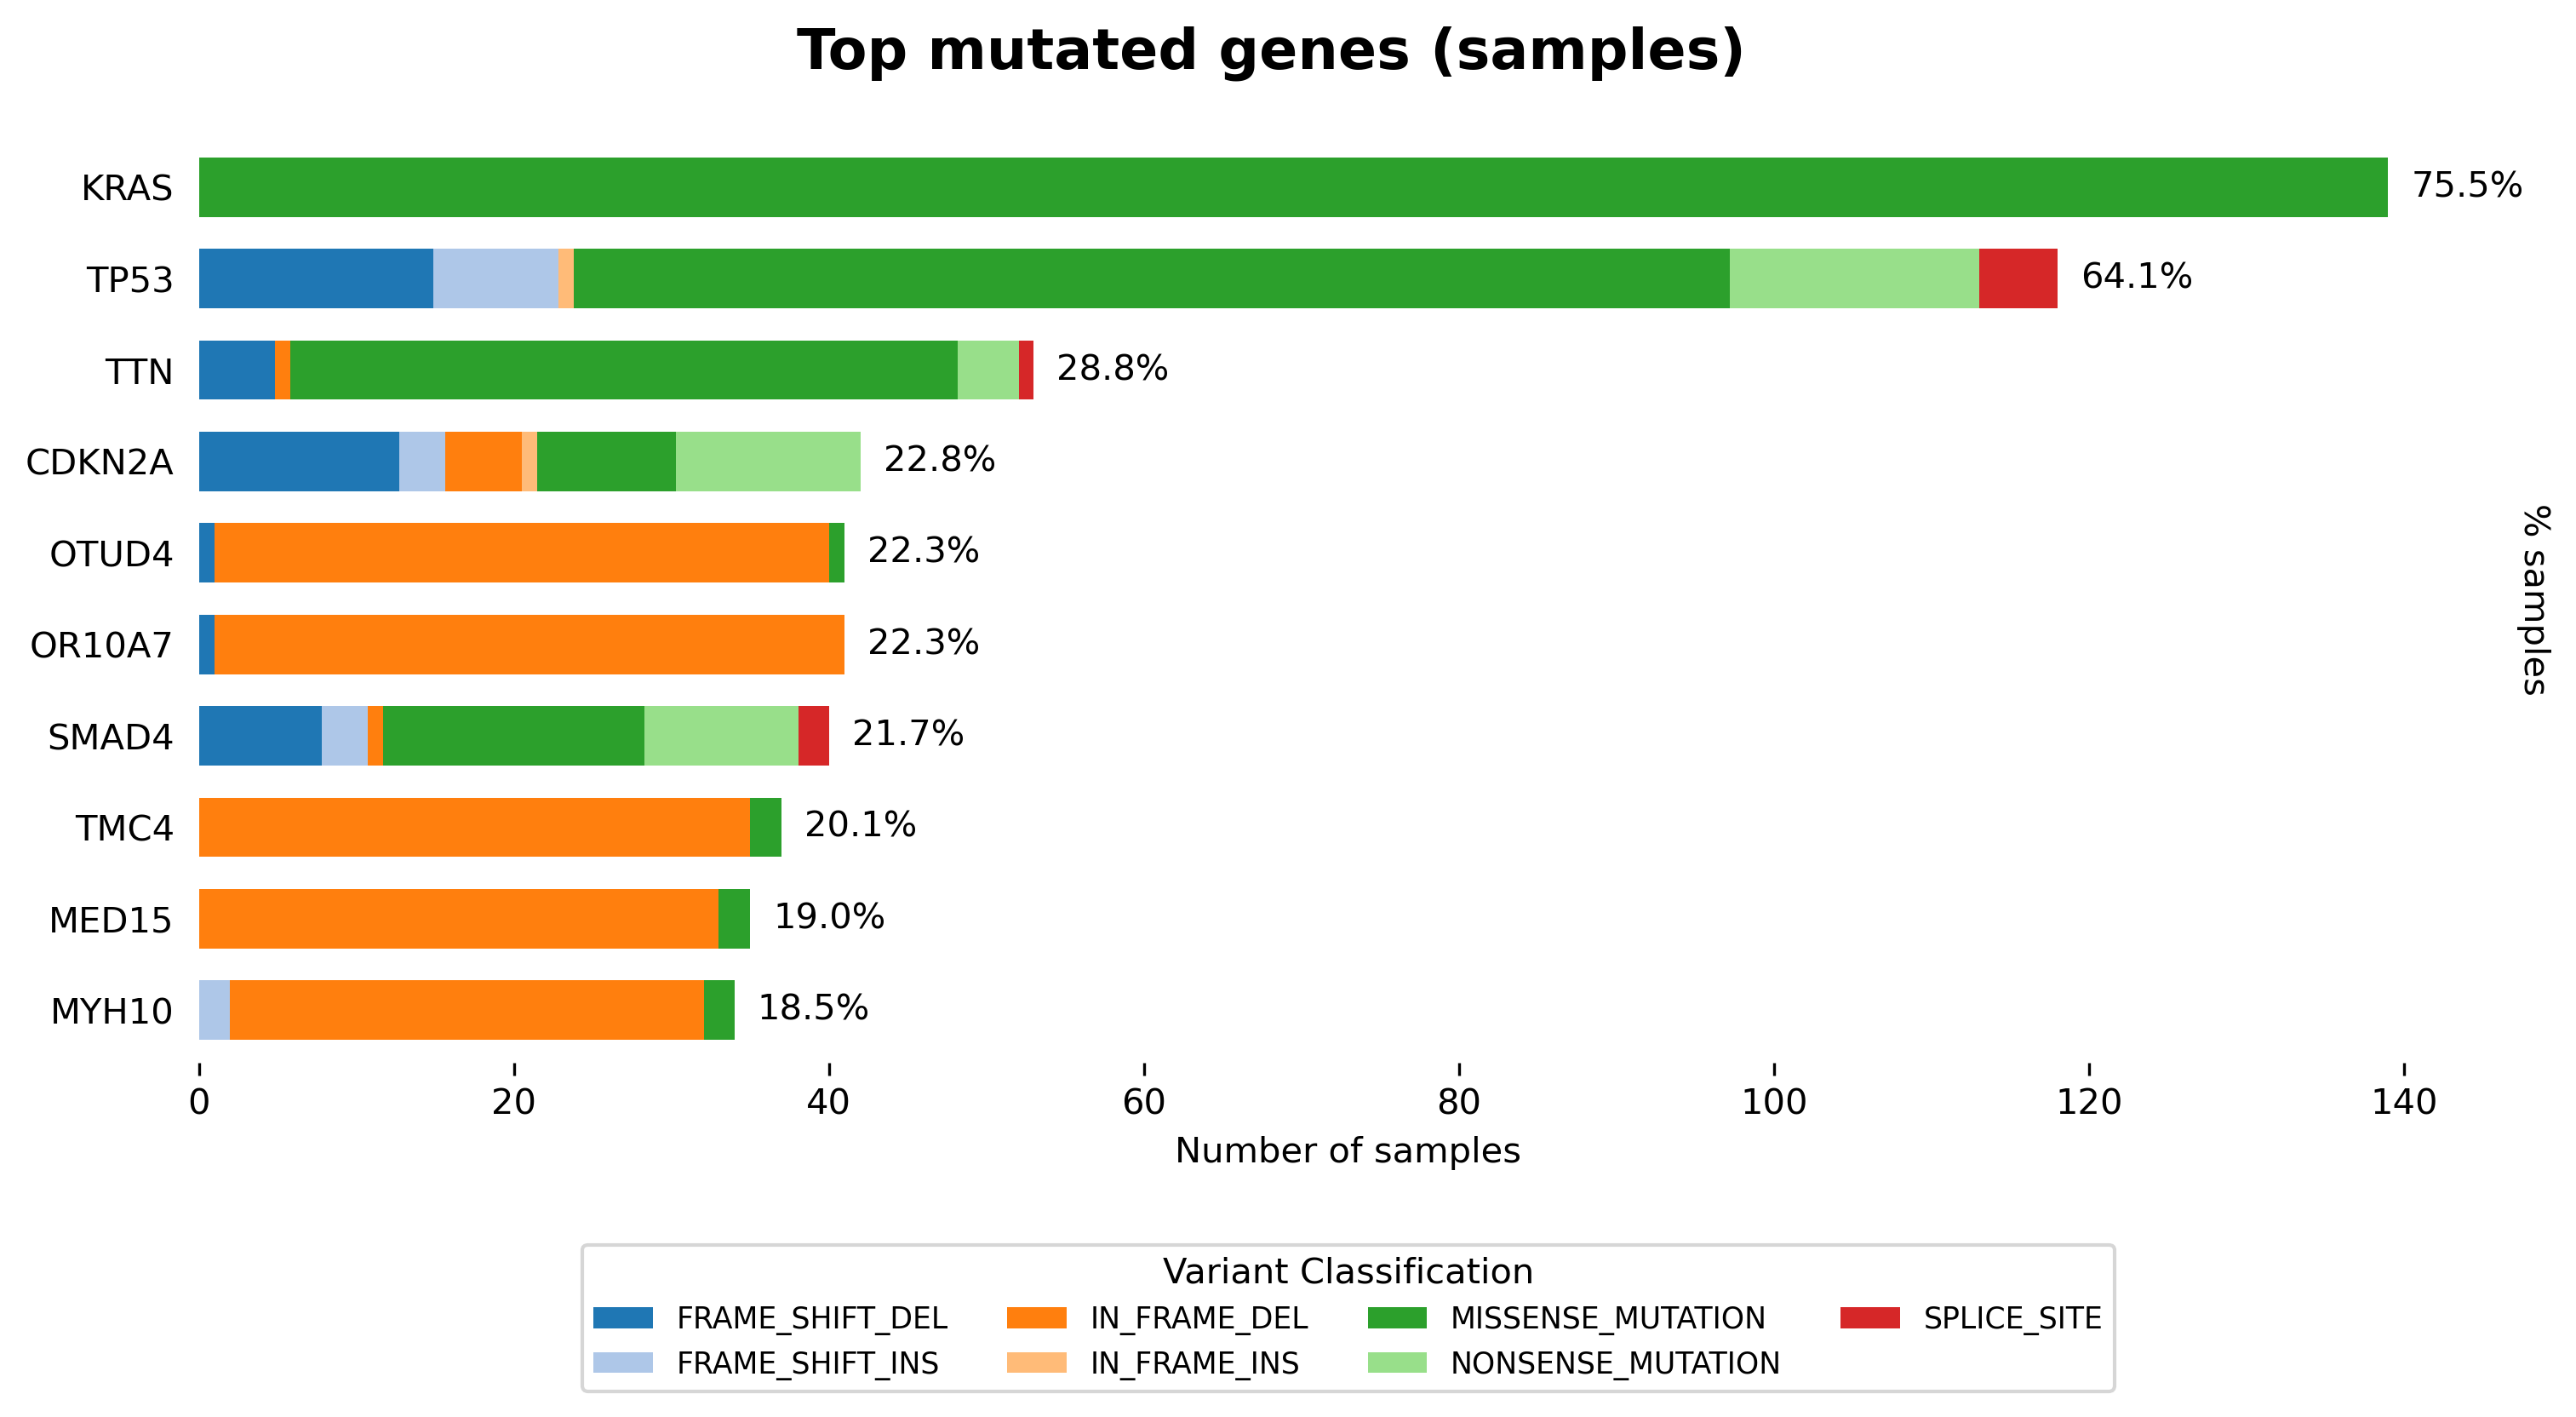

In [14]:
top_mutated_genes = mutations.top_mutated_genes_plot(mode="samples", include_silent=False)
mutations.save_figure(top_mutated_genes, out("top_mutated_genes.png"))
top_mutated_genes

Oncoplot generated: 20 genes × 184 samples (6.14s)


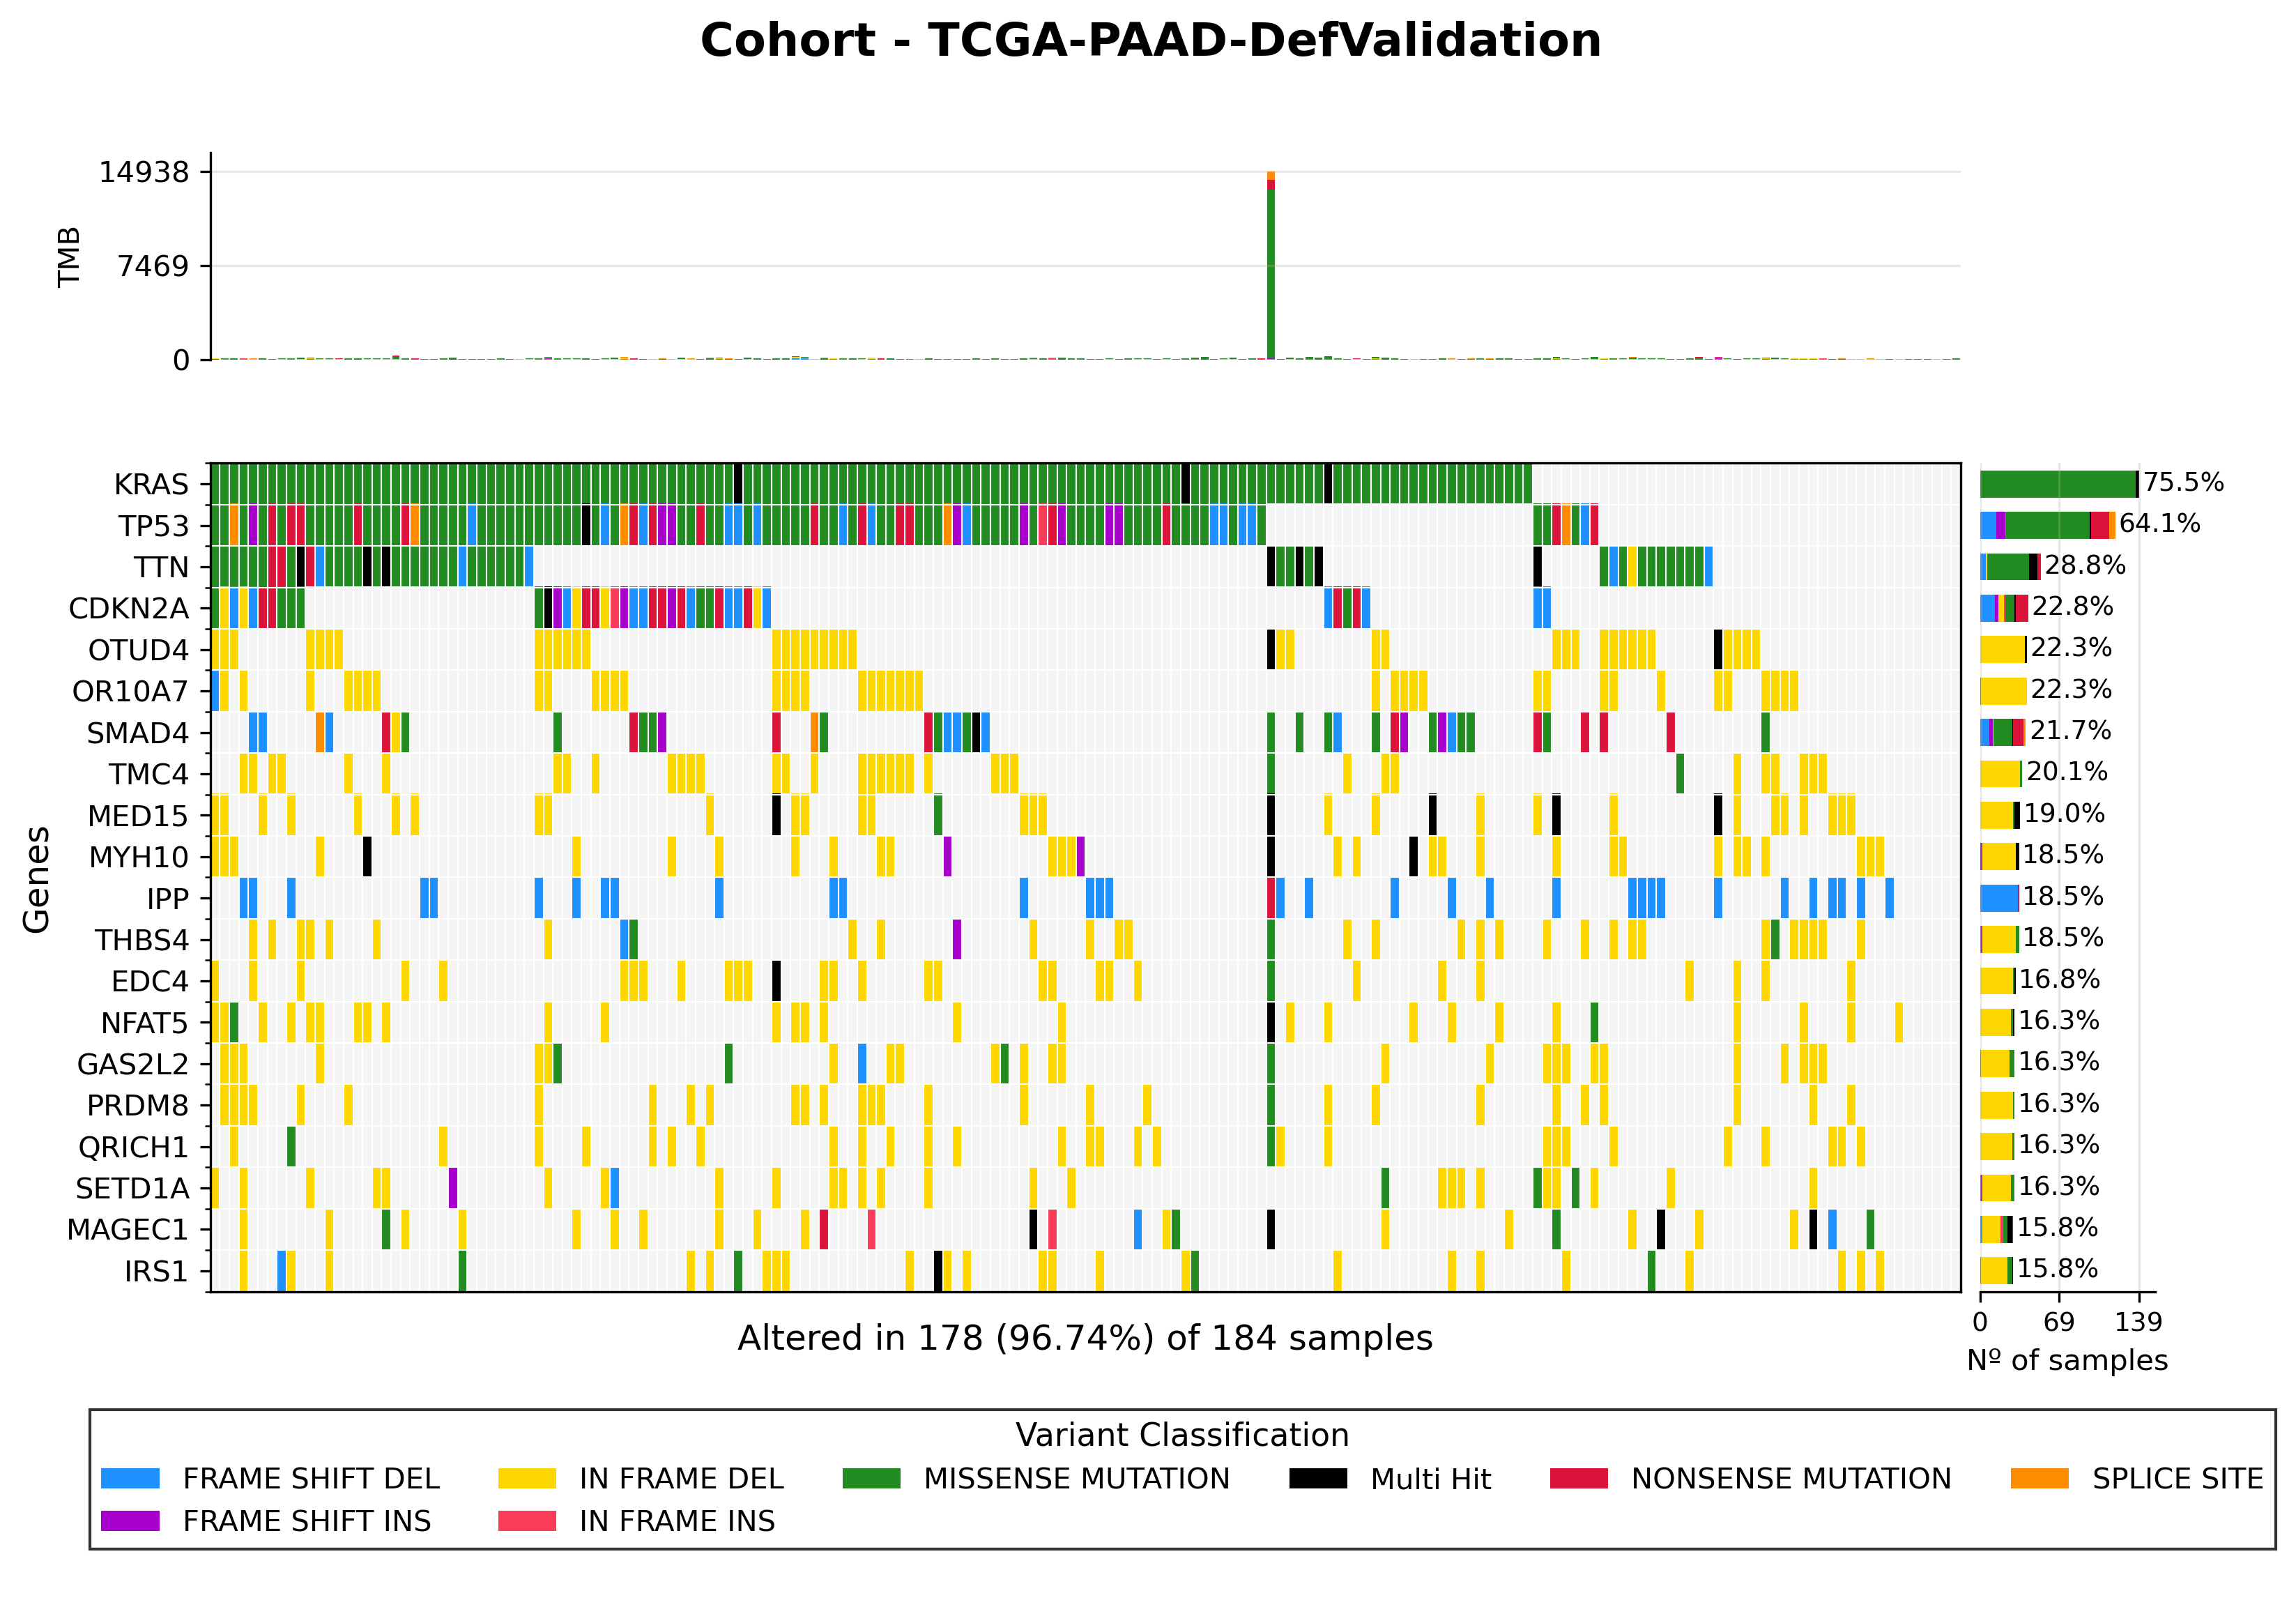

In [15]:
oncoplot_fig = mutations.oncoplot(
    figsize=(12, 9),
    title=cohort_title("Cohort"),
    gene_column="Hugo_Symbol",
    variant_column="Variant_Classification",
    ref_column="REF",
    alt_column="ALT",
    top_genes_count=20,
    include_silent=False,
    #sample_prefix="TCGA", # Not needed for TCGA prefixes
)

oncoplot_fig.savefig(out("oncoplot.png"), dpi=300, bbox_inches="tight")
oncoplot_fig

In [16]:

signature_results = mutations.mutational_signature_analysis(
    ref_genome=ref_genome,
    cosmic_path="maftools" # Optional parameter; by default cosmic_path=None uses the built-in COSMIC catalog
)

2026-09-23 16:34:17,186 | INFO | pyMut.core | Generating complete mutational signature analysis...
2026-09-23 16:34:17,731 | INFO | pyMut.analysis.mutational_signature | Using existing context column 'ref_context' for trinucleotide extraction
2026-09-23 16:34:23,678 | INFO | rpy2.situation | cffi mode is CFFI_MODE.ANY
2026-09-23 16:34:23,683 | INFO | rpy2.situation | R home found: /home/albalopez/miniconda3/envs/PyMut_env_sinVep/lib/R
2026-09-23 16:34:23,991 | INFO | rpy2.situation | R library path: 
2026-09-23 16:34:23,991 | INFO | rpy2.situation | LD_LIBRARY_PATH: 
2026-09-23 16:34:24,001 | INFO | rpy2.rinterface_lib.embedded | Default options to initialize R: rpy2, --quiet, --no-save
2026-09-23 16:34:24,306 | INFO | rpy2.rinterface | Environment variable "PWD" redefined by R and overriding existing variable. Current: "/home/albalopez", R: "/home/albalopez/Documentos/PyMut_DocsAlba"
2026-09-23 16:34:24,519 | INFO | rpy2.rinterface | R is already initialized. No need to initialize.
20

In [17]:
signature_bar_fig = mutations.signature_bar_chart(ref_genome=ref_genome, 
                                                  cosmic_path="maftools", # Optional parameter; by default cosmic_path=None uses the built-in COSMIC catalog
                                                  aetiology_path="maftools", # Optional parameter; by default aetiology_path=None 
                                                  exclude_artifacts=False, 
                                                  ignoreChr=['X'], pConstant=0.1, figsize=(14, 10))
if signature_bar_fig is not None:
    mutations.save_figure(signature_bar_fig, out("signature_bar_chart.png"))


2026-09-23 16:34:30,020 | INFO | pyMut.core | Generating signature bar chart...
2026-09-23 16:34:30,550 | INFO | pyMut.analysis.mutational_signature | Using existing context column 'ref_context' for trinucleotide extraction
2026-09-23 16:34:37,571 | INFO | pyMut.analysis.mutational_signature | NMF signature extraction completed in 1.22 seconds
2026-09-23 16:34:37,577 | INFO | pyMut.analysis.mutational_signature | Aligning extracted signatures with COSMIC catalog...
2026-09-23 16:34:37,578 | INFO | pyMut.analysis.mutational_signature | Comparing 3 signatures with COSMIC catalog
2026-09-23 16:34:37,591 | INFO | pyMut.analysis.mutational_signature | Loaded COSMIC catalog with shape (96, 68)
2026-09-23 16:34:37,592 | INFO | pyMut.analysis.mutational_signature | Aligning COSMIC catalog with standard trinucleotide context order...
2026-09-23 16:34:37,593 | INFO | pyMut.analysis.mutational_signature | COSMIC catalog successfully aligned to standard context order
2026-09-23 16:34:37,594 | INFO

📁 Figure saved: /home/albalopez/Documentos/PyMut_DocsAlba/results_tcga_paad_defvalidation_pymut/tcga_paad_defvalidation_signature_bar_chart.png (DPI: 300, margins: tight)


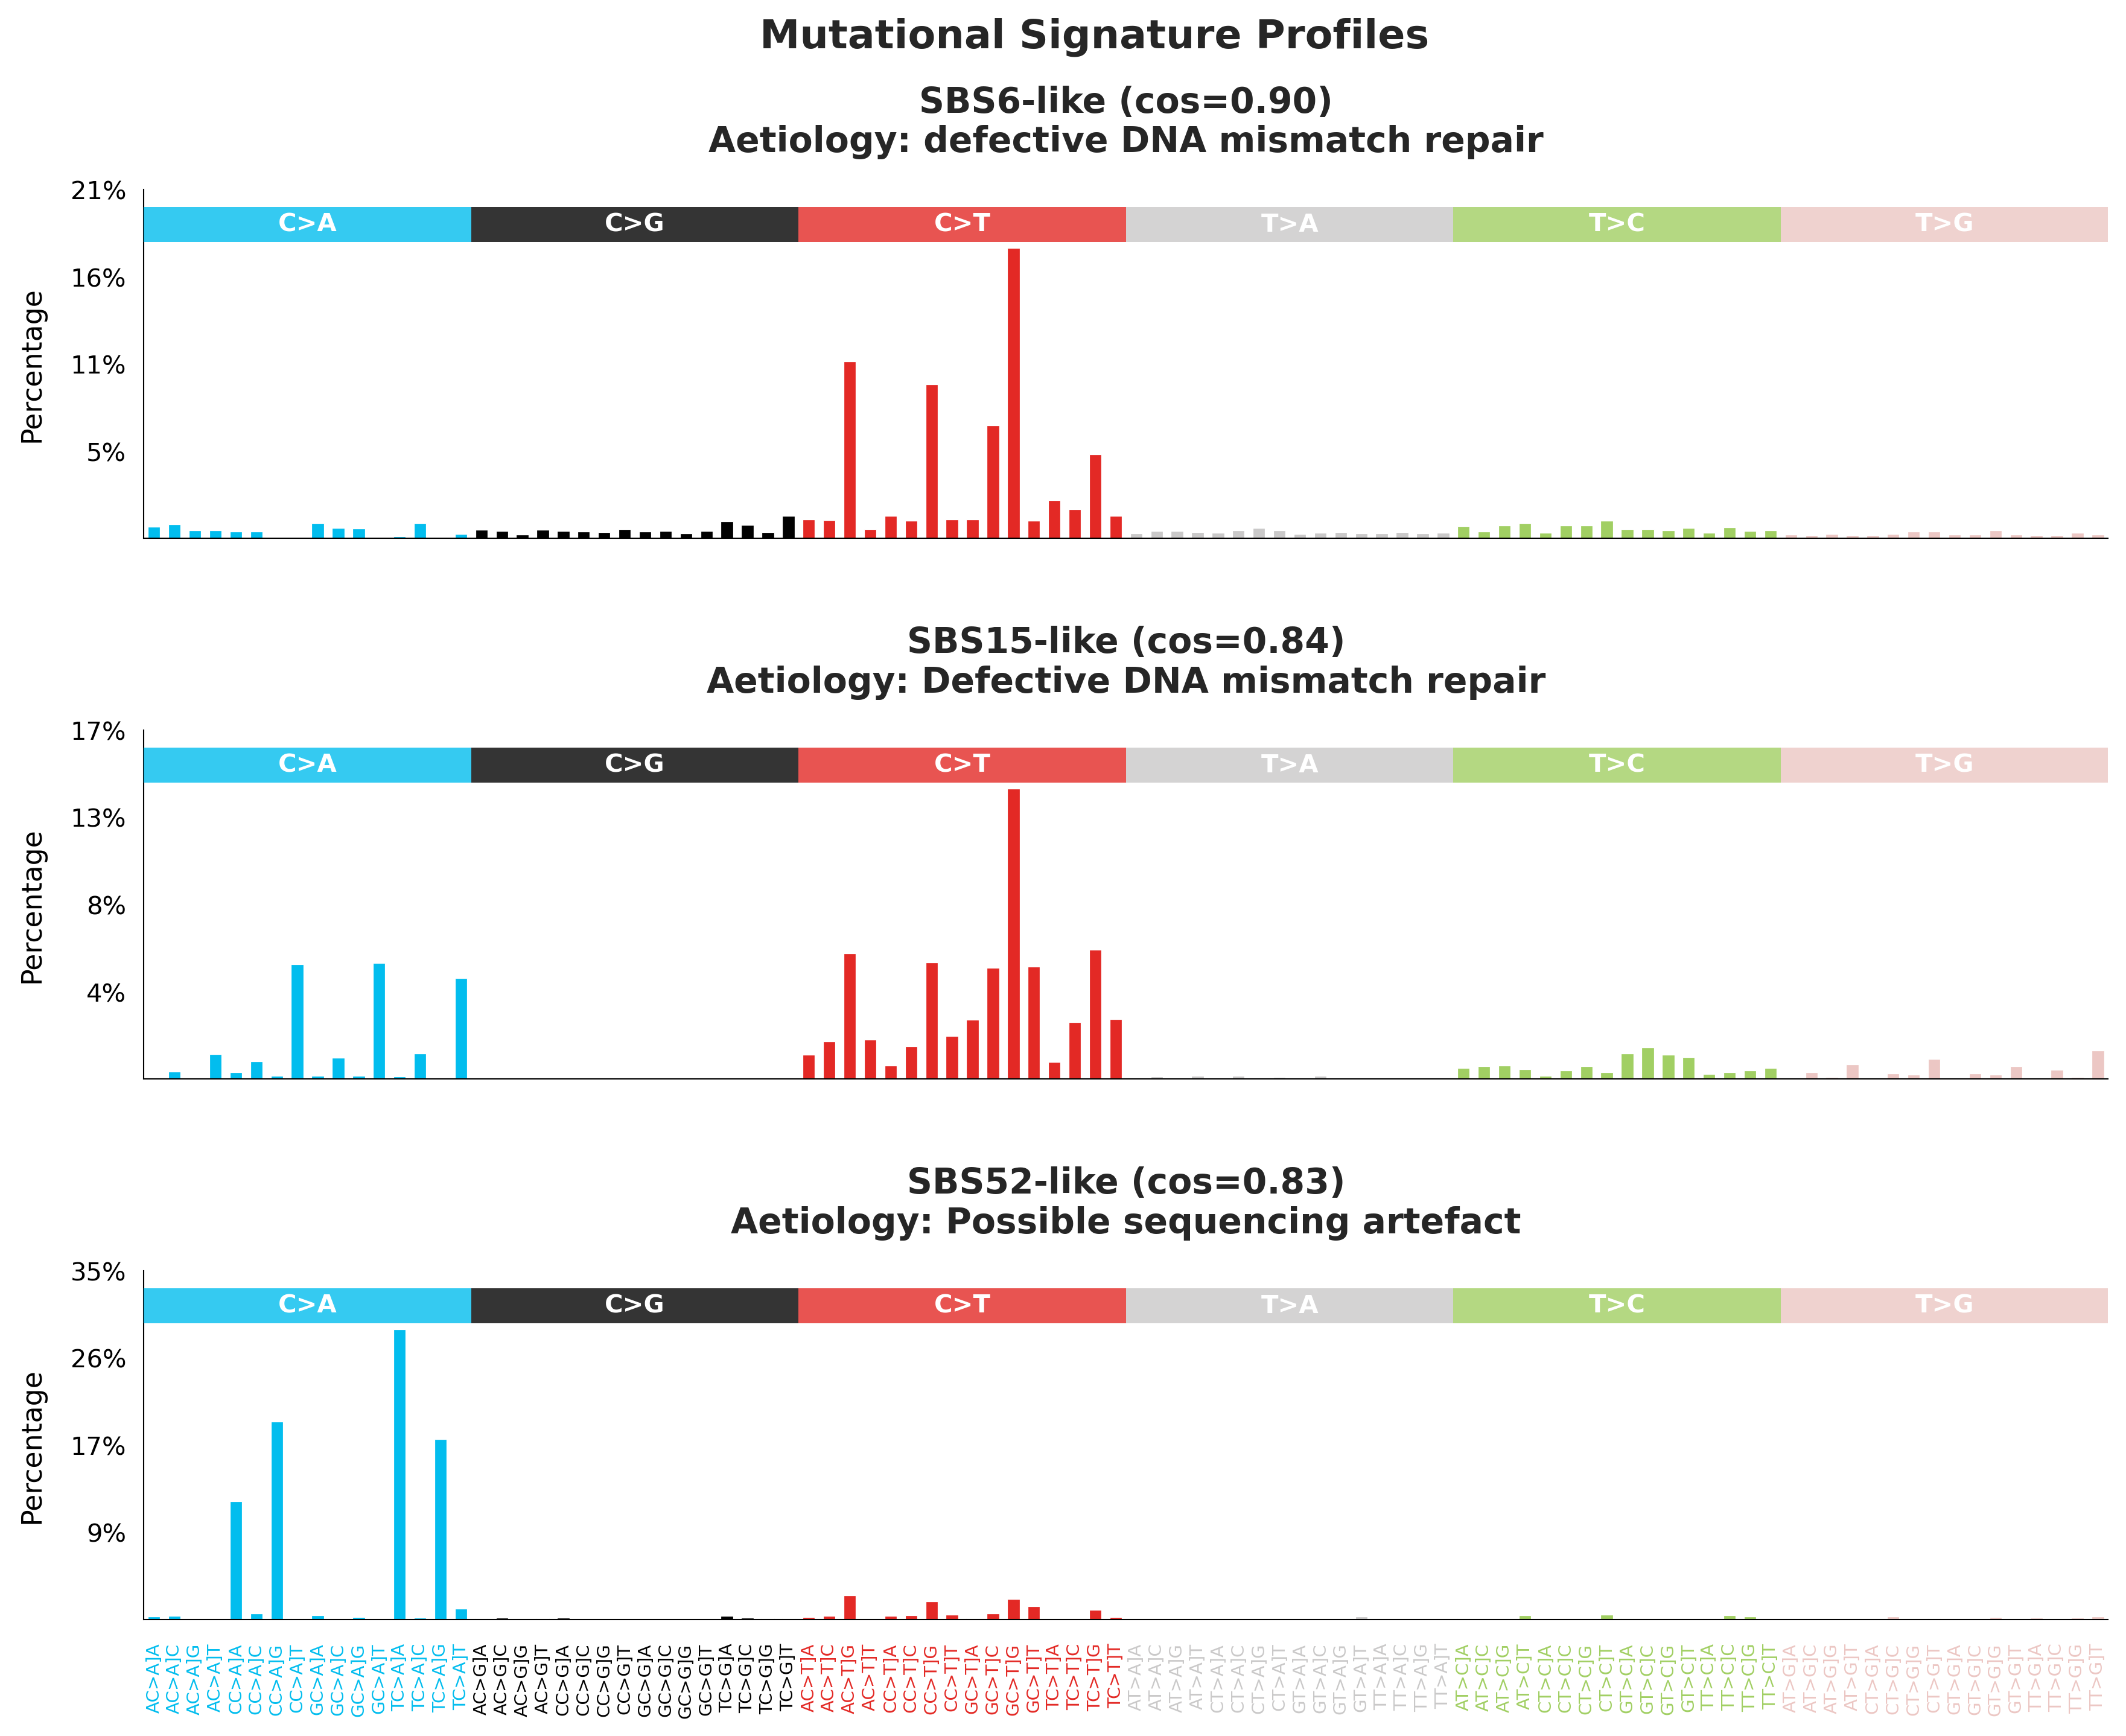

In [18]:
signature_bar_fig

2026-09-23 16:34:39,524 | INFO | pyMut.core | Generating cosine similarity heatmap...
2026-09-23 16:34:40,054 | INFO | pyMut.analysis.mutational_signature | Using existing context column 'ref_context' for trinucleotide extraction
2026-09-23 16:34:46,676 | INFO | pyMut.analysis.mutational_signature | NMF signature extraction completed in 0.74 seconds
2026-09-23 16:34:46,682 | INFO | pyMut.visualizations.mutational_signature_analysis | Generating cosine similarity heatmap...
2026-09-23 16:34:46,971 | INFO | pyMut.visualizations.mutational_signature_analysis | Cosine similarity heatmap generated in 0.29s
2026-09-23 16:34:46,994 | INFO | pyMut.core | Cosine similarity heatmap generated in 7.47s


📁 Figure saved: /home/albalopez/Documentos/PyMut_DocsAlba/results_tcga_paad_defvalidation_pymut/tcga_paad_defvalidation_cosine_similarity_heatmap.png (DPI: 300, margins: tight)


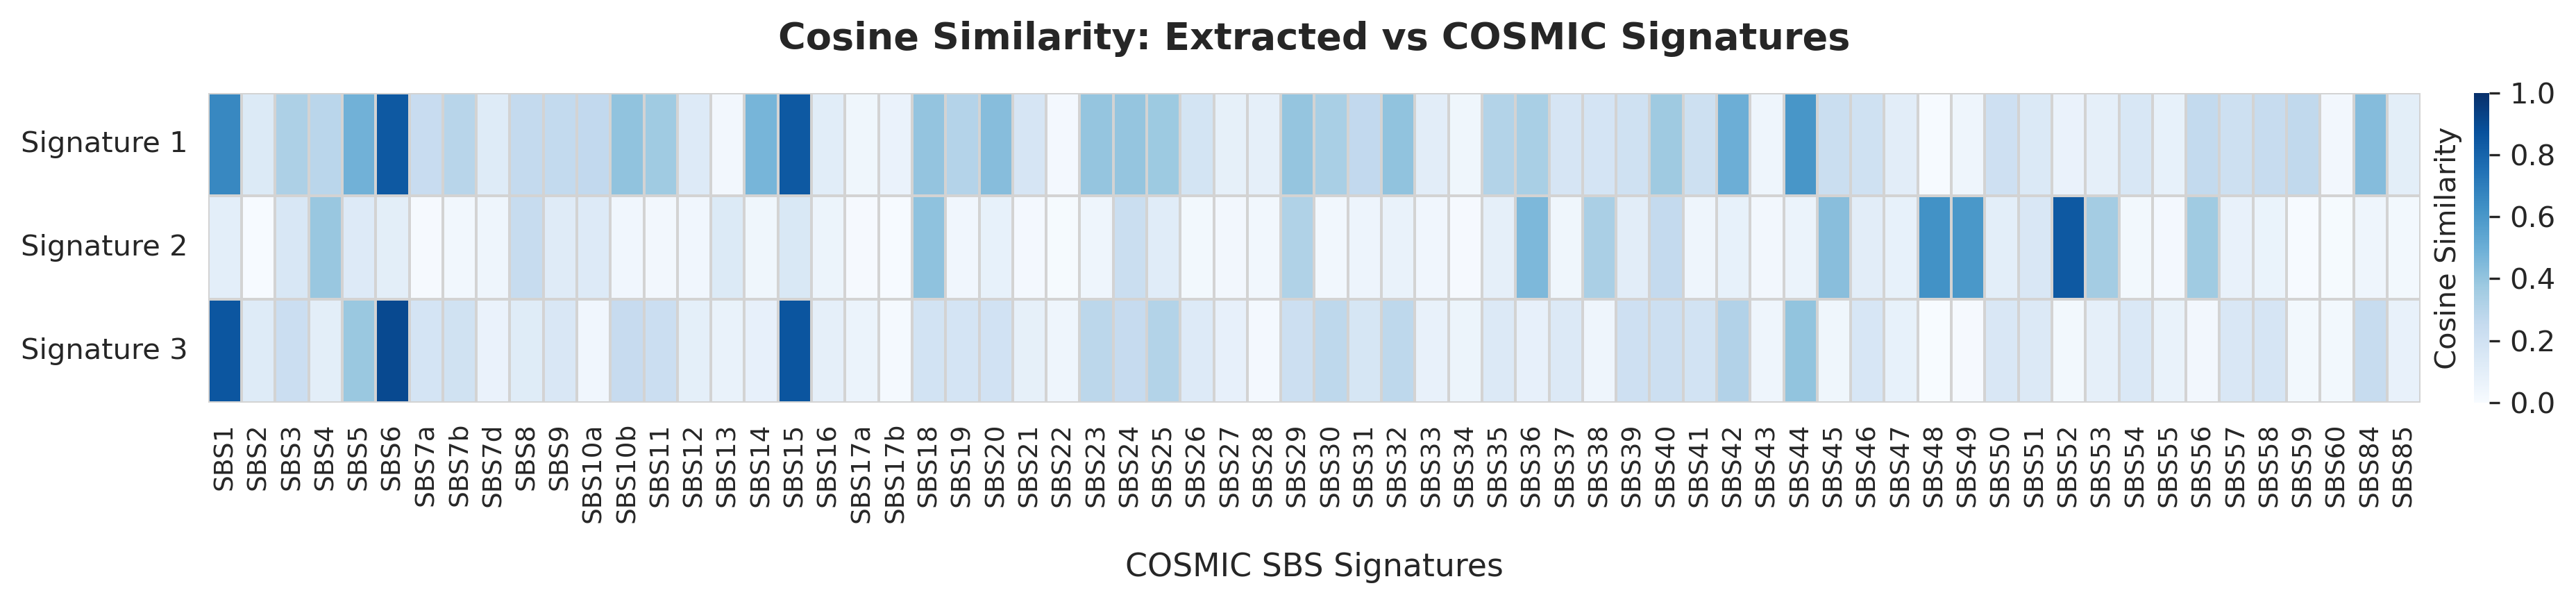

In [19]:

cosine_fig = mutations.cosine_similarity_heatmap(
    ref_genome=ref_genome,
    cosmic_path="maftools"
)
if cosine_fig is not None:
    mutations.save_figure(cosine_fig, out("cosine_similarity_heatmap.png"))
cosine_fig

In [20]:
import pandas as pd, hashlib
from pathlib import Path

p = Path("/home/albalopez/Documentos/PyMut_DocsAlba/data/references/maftools_SBS_catalog.tsv")
df = pd.read_csv(p, sep="\t")
print("shape:", df.shape)                      # te saldrá (96, 87), no (96, 68)
print("md5:", hashlib.md5(p.read_bytes()).hexdigest())  # NO será a61c303b...
print("últimas columnas:", df.columns[-5:].tolist())    # verás SBS86, SBS87...

shape: (96, 68)
md5: a61c303b3bbbe8f566d9c74f1c04de4b
últimas columnas: ['SBS58', 'SBS59', 'SBS60', 'SBS84', 'SBS85']


2026-09-23 16:34:49,018 | INFO | pyMut.visualizations.somatic_interactions | Somatic interactions plot: 28,535 variants, 184 samples, 25 genes analyzed in 1.16s


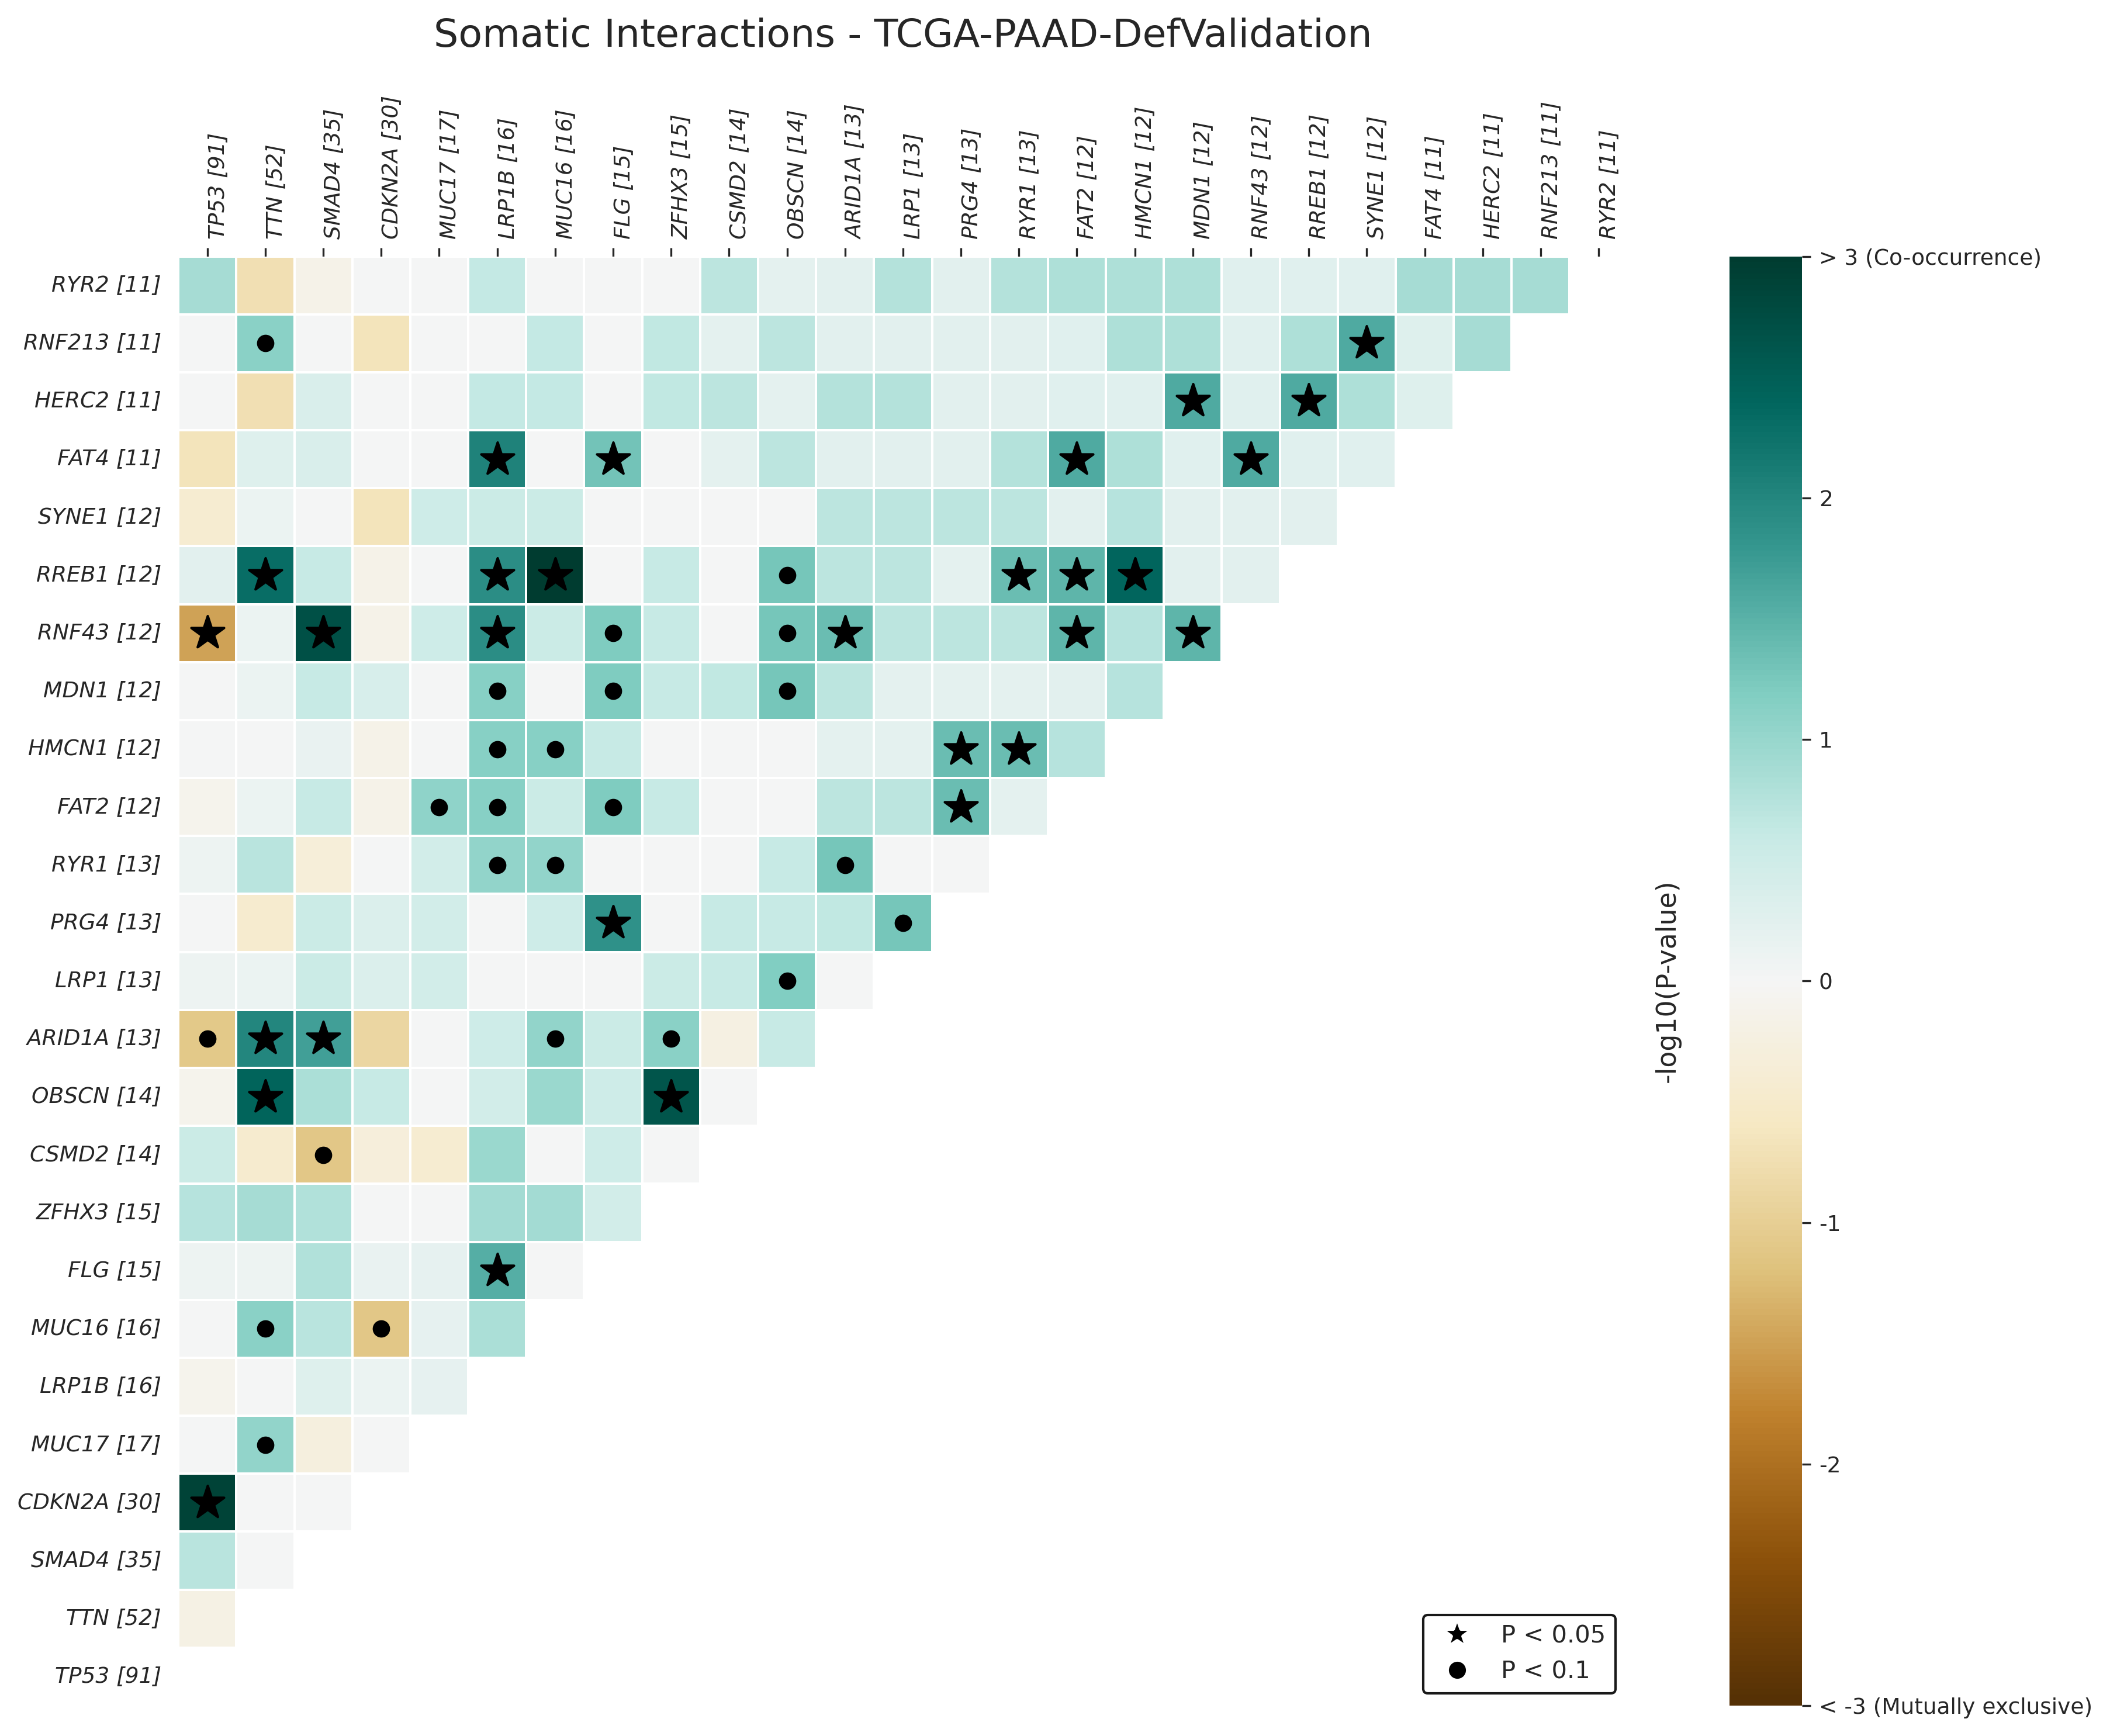

In [21]:
mutations.somatic_interactions(
    title=cohort_title("Somatic Interactions"),
    top_genes=25,
    figsize=(13, 10),
    fdr_correction=False
)

2026-09-23 16:34:50,904 | INFO | pyMut.visualizations.somatic_interactions | Somatic interactions plot: 28,535 variants, 184 samples, 25 genes analyzed in 1.05s


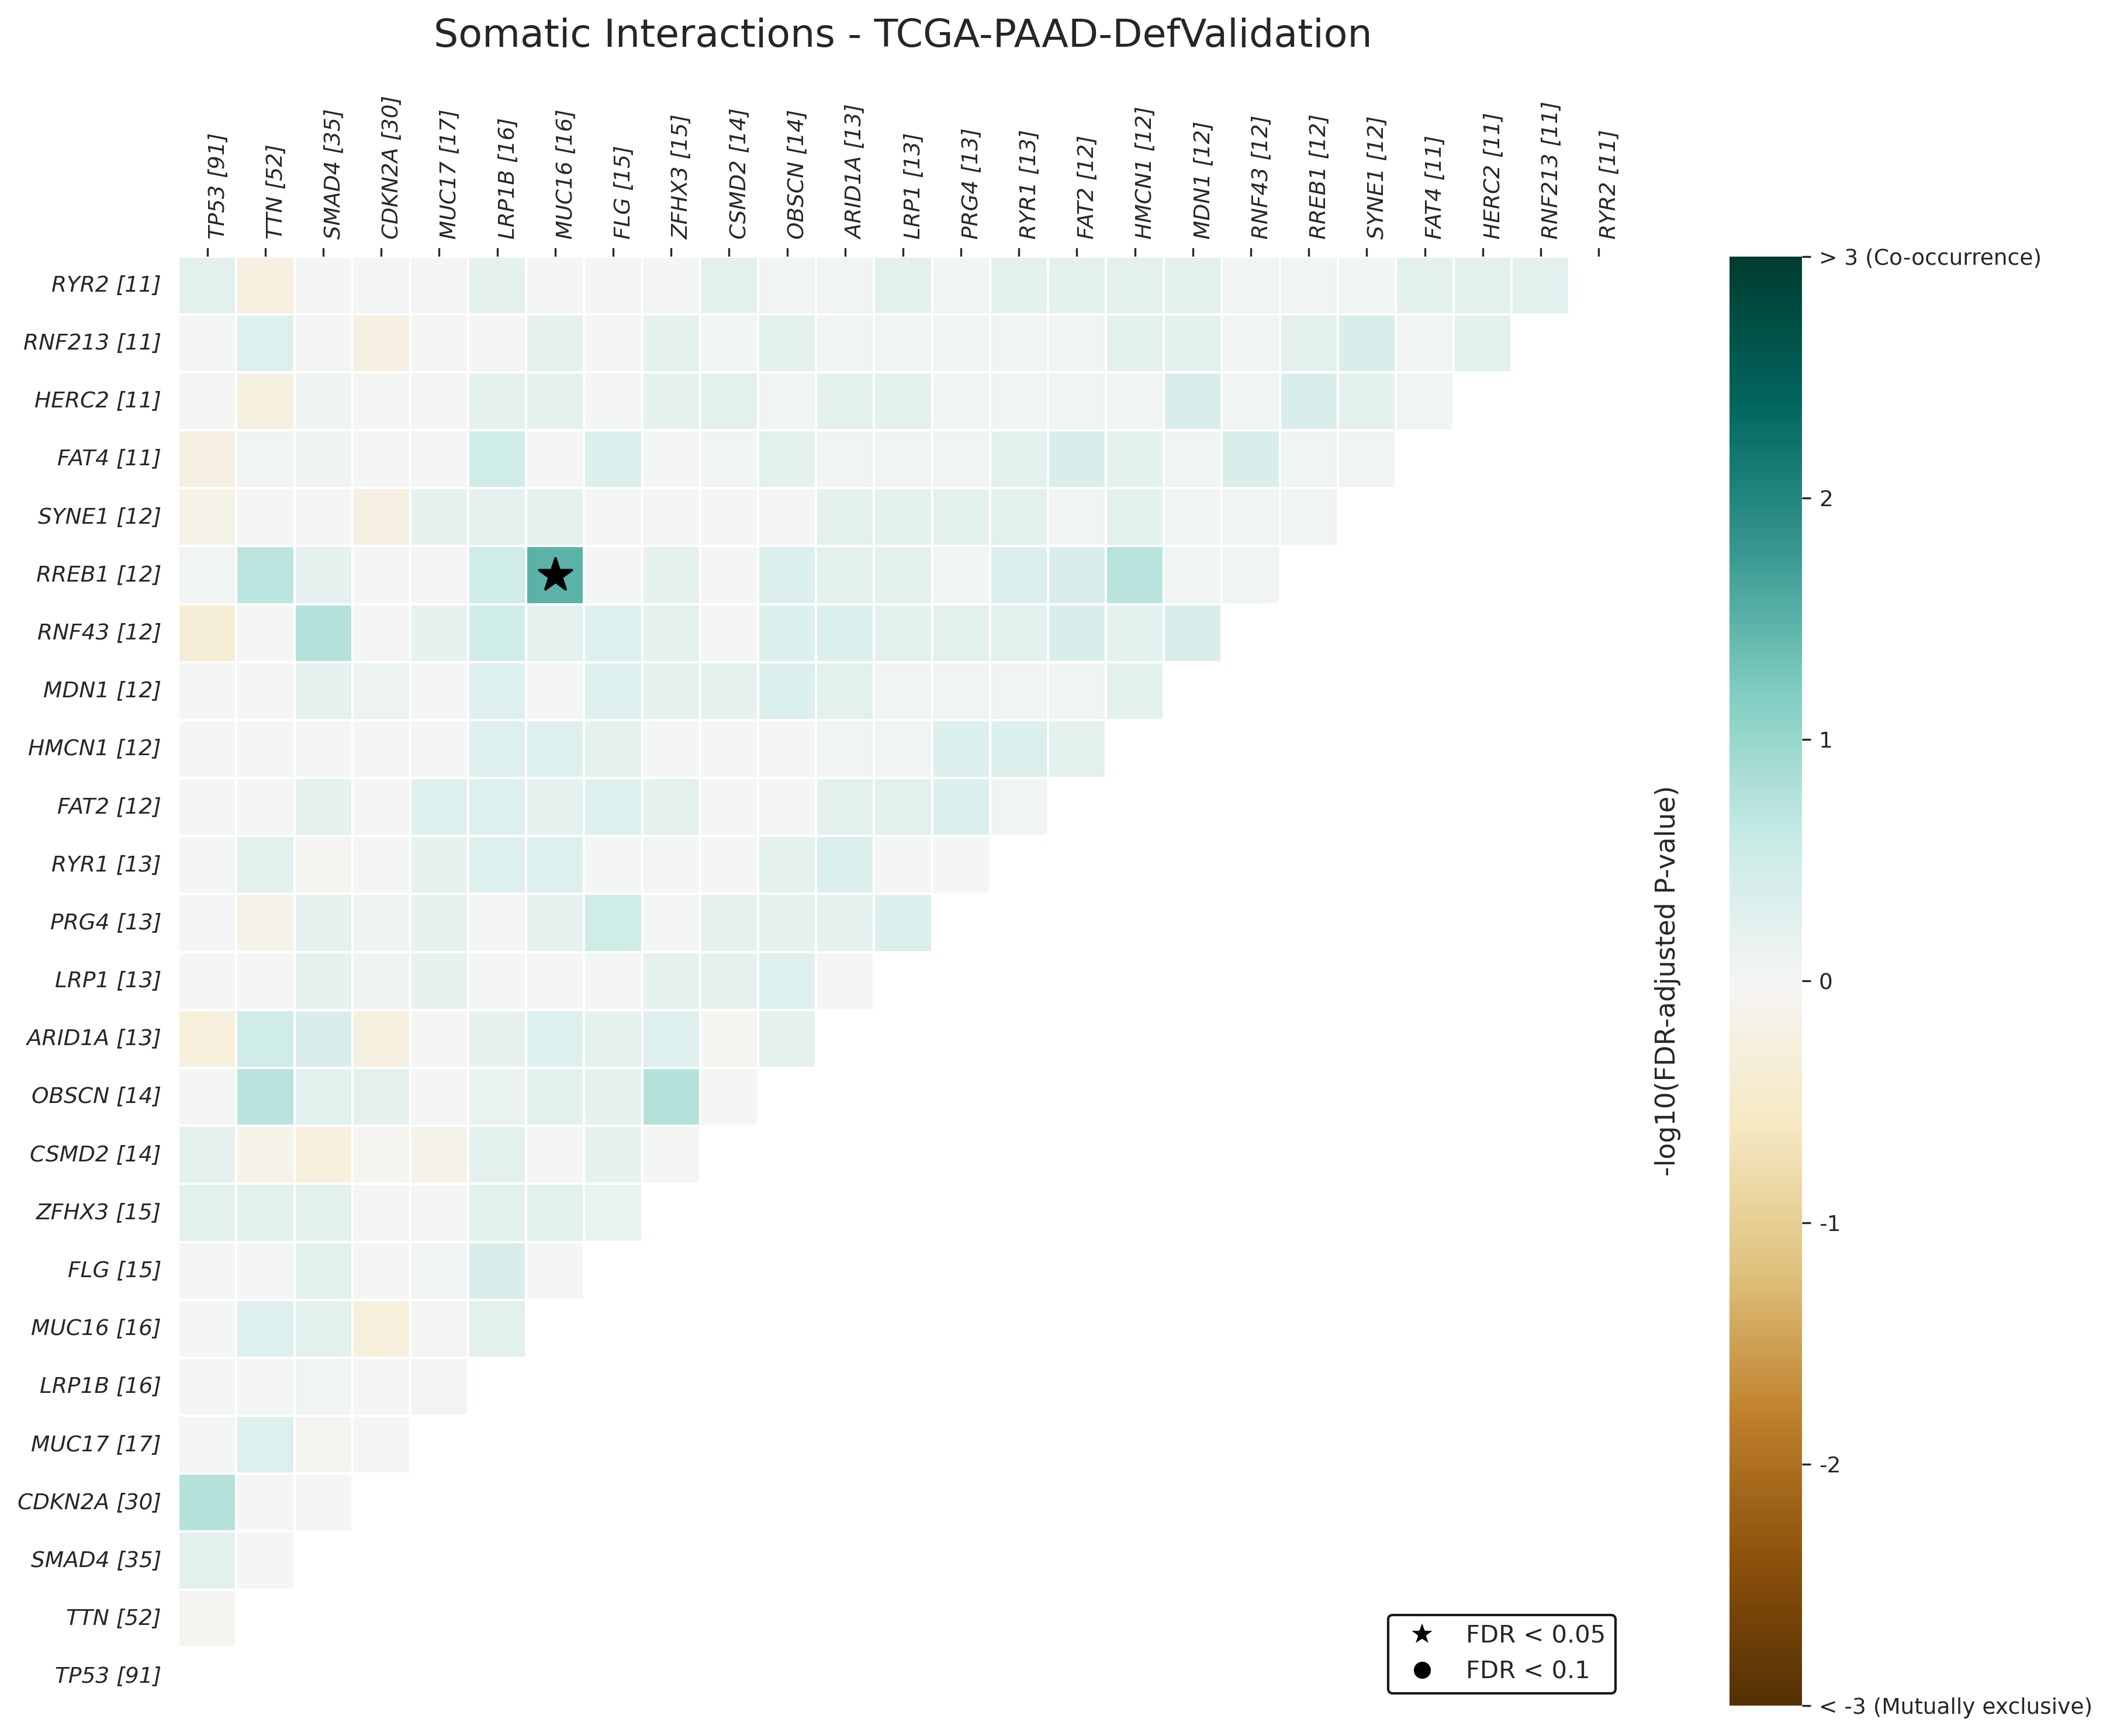

In [22]:
mutations.somatic_interactions(
    title=cohort_title("Somatic Interactions"),
    top_genes=25,
    figsize=(13, 10),
    fdr_correction=True
)

In [23]:
table = mutations.somatic_interactions_table(top_genes=25)
print(table)
#table.to_csv("/home/albalopez/Documentos/PyMut/TableS1.csv", index=False)

2026-09-23 16:34:52,169 | INFO | pyMut.visualizations.somatic_interactions | Somatic interactions table: 28,535 variants, 184 samples, 25 genes, 300 pairwise tests in 0.60s


     Gene 1  Gene 2  Altered samples gene 1  Altered samples gene 2  \
0     MUC16   RREB1                      16                      12   
1      TP53  CDKN2A                      91                      30   
2     SMAD4   RNF43                      35                      12   
3     ZFHX3   OBSCN                      15                      14   
4       TTN   OBSCN                      52                      14   
..      ...     ...                     ...                     ...   
295   MUC17   OBSCN                      17                      14   
296   MUC16     FLG                      16                      15   
297   MUC17   ZFHX3                      17                      15   
298  CDKN2A   HERC2                      30                      11   
299  CDKN2A    RYR2                      30                      11   

     Both altered  Only gene 1 altered  Only gene 2 altered  Neither altered  \
0               6                   10                    6        

2026-09-23 16:34:52,862 | WARNING | pyMut.visualizations.lollipop_plot | label_pos [882] doesn't match any mutated position. Mutated positions found: [118, 254, 398, 517, 604, 615, 790, 804]
2026-09-23 16:34:52,991 | INFO | pyMut.visualizations.lollipop_plot | Lollipop plot for DNMT3A created in 0.80s (9 mutations, 8 AA changes)


📁 Figure saved: /home/albalopez/Documentos/PyMut_DocsAlba/results_tcga_paad_defvalidation_pymut/tcga_paad_defvalidation_DNMT3A_lollipop.png (DPI: 300, margins: tight)


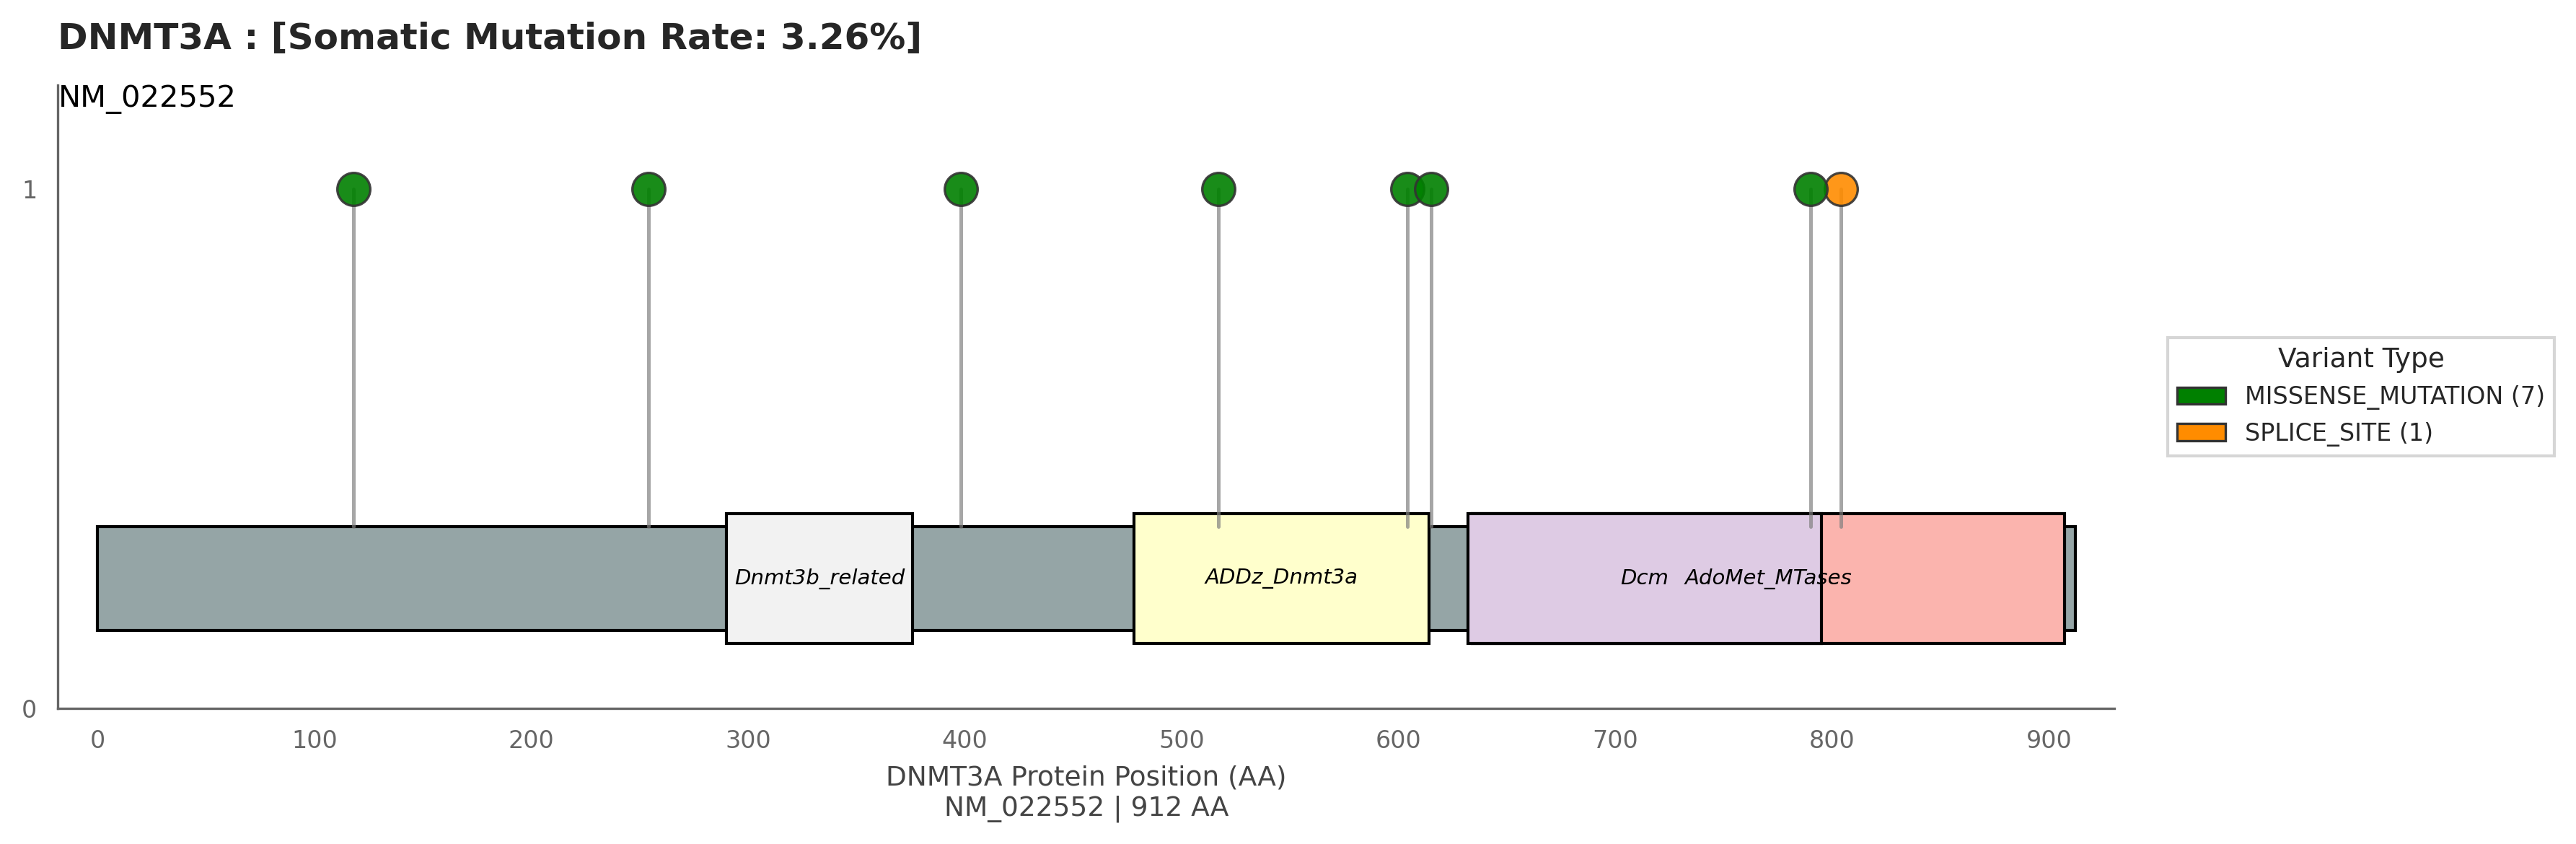

In [24]:

lollipop_fig_dnmt3a = mutations.lollipop_plot(
    gene="DNMT3A",
    aa_col="Protein_Change",
    transcript_id="NM_022552",
    #label_top_n=3,
    label_pos = 882, 
    figsize=(12, 4)
)
if lollipop_fig_dnmt3a is not None:
    mutations.save_figure(lollipop_fig_dnmt3a, out("DNMT3A_lollipop.png"))
lollipop_fig_dnmt3a

2026-09-23 16:34:54,771 | INFO | pyMut.visualizations.lollipop_plot | Lollipop plot for TP53 created in 1.31s (92 mutations, 88 AA changes)


📁 Figure saved: /home/albalopez/Documentos/PyMut_DocsAlba/results_tcga_paad_defvalidation_pymut/tcga_paad_defvalidation_TP53_lollipop.png (DPI: 300, margins: tight)


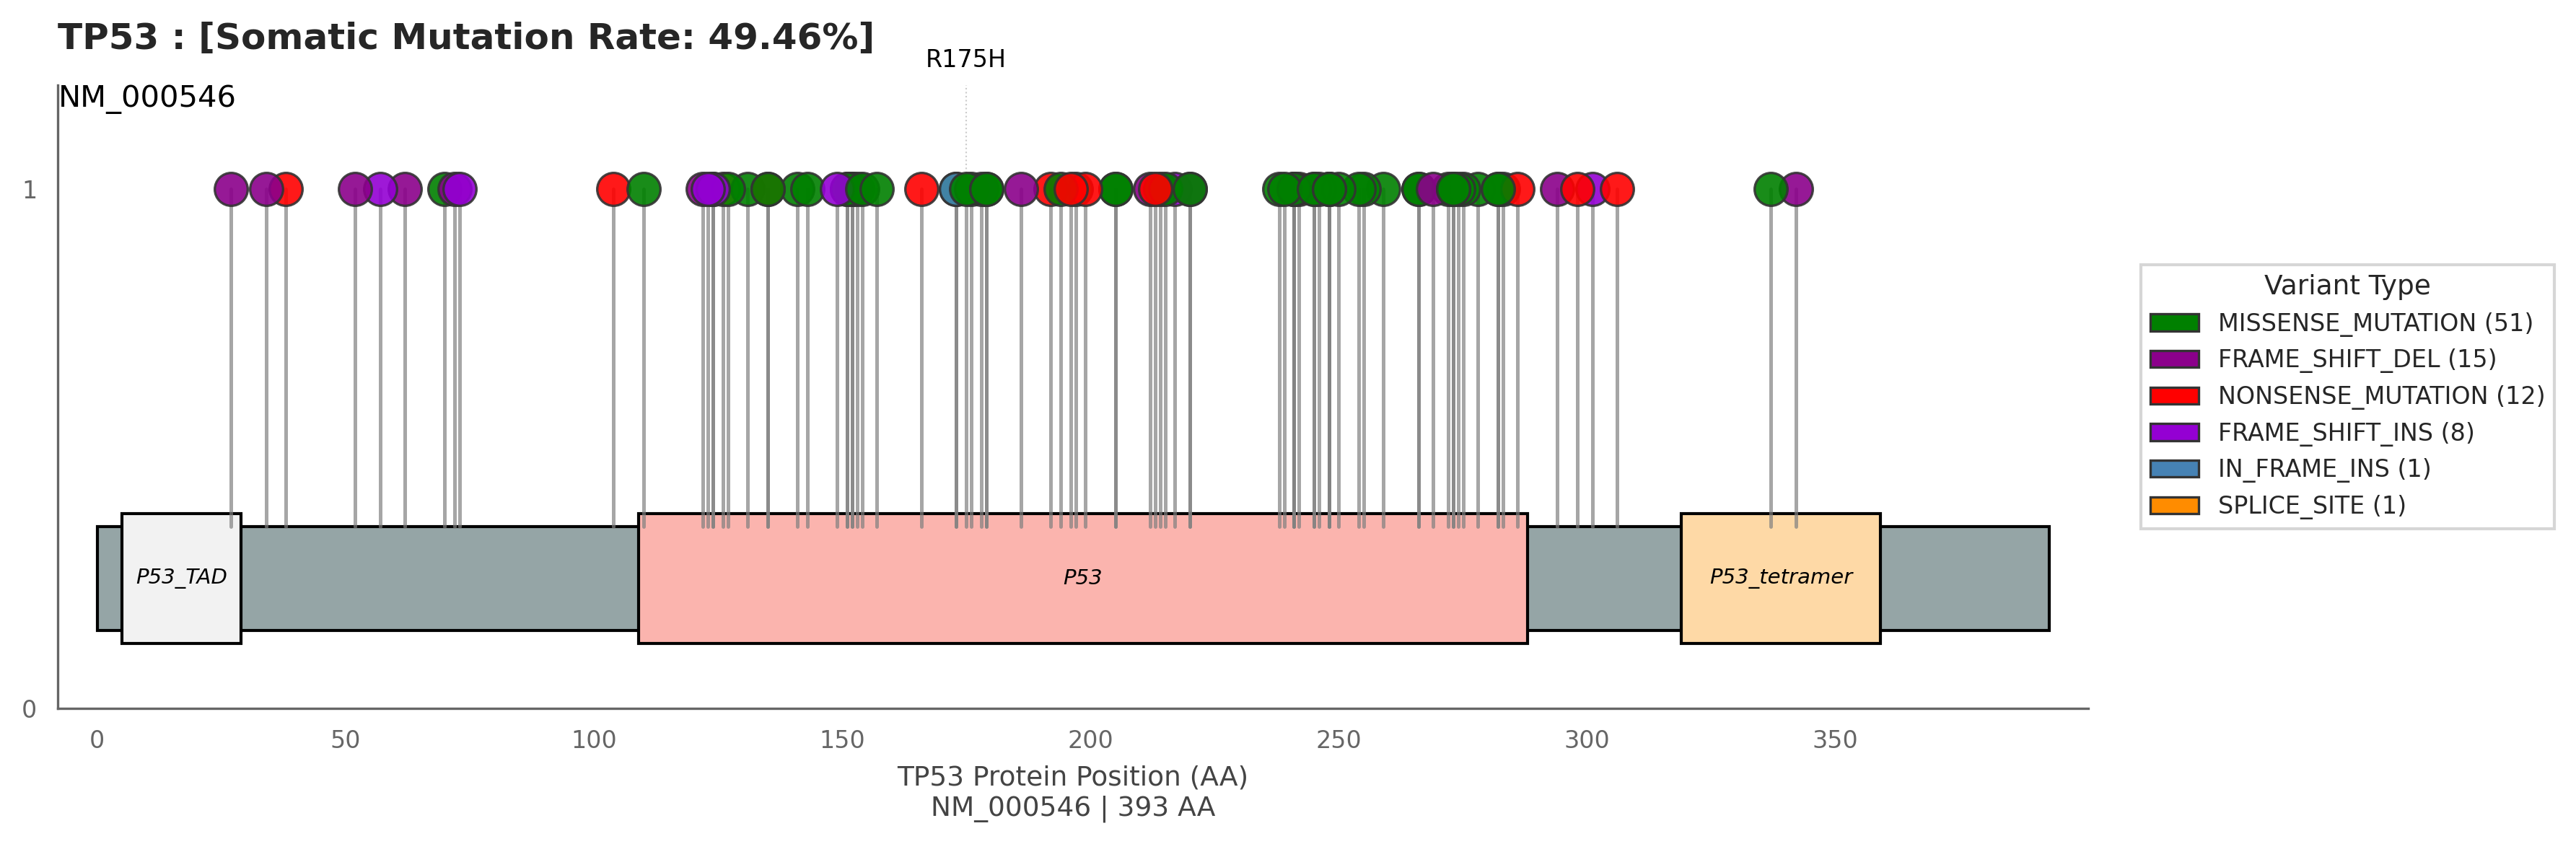

In [25]:
lollipop_fig_tp53 = mutations.lollipop_plot(
    gene="TP53",
    aa_col="Protein_Change",
    transcript_id="NM_000546",
    #label_top_n=3,
    label_pos = 175, 
    figsize=(12, 4)
)
if lollipop_fig_tp53 is not None:
    mutations.save_figure(lollipop_fig_tp53, out("TP53_lollipop.png"))
lollipop_fig_tp53

In [27]:
# Archivos de entrada 
maf_path = WORKING_DIR / "data/tcga_laml_VEP_annotated.maf.gz" #tcga_laml.maf.gz #PAAD-TB.final_analysis.maf #tcga_laml_VEP_annotated.maf.gz
mutations = read_maf(
    maf_path,
    assembly="37",
    consolidate_variants=True
)
print(mutations.data.shape)
print(mutations.data.head())

2026-09-23 16:40:54,460 | INFO | pyMut.input | Starting MAF reading: /home/albalopez/Documentos/PyMut_DocsAlba/data/tcga_laml_VEP_annotated.maf.gz
2026-09-23 16:40:54,482 | INFO | pyMut.input | Reading MAF with 'pyarrow' engine…
2026-09-23 16:40:54,535 | INFO | pyMut.input | Reading with 'pyarrow' completed.
2026-09-23 16:40:54,551 | INFO | pyMut.input | Detected 193 unique samples.
2026-09-23 16:40:54,759 | INFO | pyMut.input | Consolidating duplicate variants across samples...
2026-09-23 16:40:54,760 | INFO | pyMut.input | Consolidating variants using optimized pure NumPy arrays...
2026-09-23 16:40:54,796 | WARNING | pyMut.input | Consolidating duplicate variants is discarding differing per-row annotation values in 3 column(s) (Tumor_Sample_Barcode, i_TumorVAF_WU, i_transcript_name) - only the first occurrence is kept for each variant. Sample genotypes are unaffected. Use consolidate_variants=False if you need to preserve these columns exactly.
/home/albalopez/miniconda3/envs/PyMut_e

(2091, 237)
   CHROM        POS ID REF ALT QUAL FILTER TCGA-AB-2988 TCGA-AB-2869  \
0  chr17   67170917  .   T   C    .      .          T|C          T|T   
1   chr1   94490594  .   C   T    .      .          C|C          C|T   
2   chr2  169780250  .   G   A    .      .          G|G          G|G   
3  chr16   48244997  .   G   A    .      .          G|G          G|G   
4  chr17   48760974  .   C   T    .      .          C|C          C|C   

  TCGA-AB-3009  ... VEP_SYMBOL_SOURCE VEP_HGNC_ID         VEP_ENSP  \
0          T|T  ...              HGNC          30  ENSP00000269081   
1          C|C  ...              HGNC          34  ENSP00000359245   
2          G|A  ...              HGNC          42  ENSP00000263817   
3          G|G  ...              HGNC       14639  ENSP00000378230   
4          C|C  ...              HGNC          54  ENSP00000285238   

  VEP_SWISSPROT                              VEP_TREMBL    VEP_UNIPARC  \
0   ABCAA_HUMAN                            K7ERP5_HUMAN  UPI

In [28]:
annotated_basic = mutations.annotate_pfam(strategy="basic")

Using existing database: /home/albalopez/miniconda3/envs/PyMut_env_sinVep/lib/python3.10/site-packages/pyMut/data/resources/data.duckdb


2026-09-23 16:40:55,728 | INFO | pyMut.analysis.pfam_annotation | Gene symbol + position (maftools-style): 1,046/2,091 variants mapped to a Pfam domain
2026-09-23 16:40:55,732 | INFO | pyMut.analysis.pfam_annotation | strategy='basic': 1,046/2,091 coding-relevant variants (50.02%) mapped to a Pfam domain via gene symbol + protein change.


In [29]:
annotated_extended = mutations.annotate_pfam(strategy="extended")

Using existing database: /home/albalopez/miniconda3/envs/PyMut_env_sinVep/lib/python3.10/site-packages/pyMut/data/resources/data.duckdb


2026-09-23 16:40:56,115 | INFO | pyMut.analysis.pfam_annotation | Gene symbol + position (maftools-style): 1,046/2,091 variants mapped to a Pfam domain
2026-09-23 16:40:58,145 | INFO | pyMut.analysis.pfam_annotation | UniProt resolution summary:
2026-09-23 16:40:58,146 | INFO | pyMut.analysis.pfam_annotation |    Total identifiers processed: 1,552
2026-09-23 16:40:58,147 | INFO | pyMut.analysis.pfam_annotation |    Direct accessions: 0
2026-09-23 16:40:58,148 | INFO | pyMut.analysis.pfam_annotation |    Resolved via short_name: 1,469
2026-09-23 16:40:58,148 | INFO | pyMut.analysis.pfam_annotation |    Resolved via external ID: 0
2026-09-23 16:40:58,148 | INFO | pyMut.analysis.pfam_annotation |    Unresolved: 83
2026-09-23 16:41:02,034 | INFO | pyMut.analysis.pfam_annotation | Variants annotated with PFAM: 1059/1853
2026-09-23 16:41:14,506 | INFO | pyMut.analysis.pfam_annotation | strategy='extended': 1,823/2,091 variants (87.18%) mapped to a Pfam domain.
2026-09-23 16:41:14,507 | INFO 

In [30]:

summary_pfam_basic = annotated_basic.pfam_domains(
    summarize_by="PfamDomain",
    top_n=1000000
)

print(summary_pfam_basic.head())


2026-09-23 16:41:14,695 | INFO | pyMut.analysis.pfam_annotation | Amino acid position column (from previous annotate_pfam): 'VEP_Protein_position'
2026-09-23 16:41:14,731 | INFO | pyMut.analysis.pfam_annotation | 892/1,644 variants (54.3%) mapped to a Pfam domain


     pfam_id        pfam_name  \
0    cl09925         PKc_like   
1  pfam00001            7tm_1   
2       None          COG5048   
3    cd11304  Cadherin_repeat   
4    cd08367              P53   

                                    pfam_description  n_genes  n_variants  \
0                  Protein Kinases, catalytic domain        5          40   
1        7 transmembrane receptor (rhodopsin family)       24          24   
2  FOG: Zn-finger [General function prediction only]       17          17   
3                      Cadherin tandem repeat domain       16          15   
4                             P53 DNA-binding domain        2          15   

   pct_of_mapped  pct_of_considered     display_name  \
0           4.48               2.43         PKc_like   
1           2.69               1.46            7tm_1   
2           1.91               1.03          COG5048   
3           1.68               0.91  Cadherin_repeat   
4           1.68               0.91              P53   

 

In [31]:

summary_pfam_extended = annotated_extended.pfam_domains(
    summarize_by="PfamDomain",
    top_n=1000000
)

print(summary_pfam_extended.head())

2026-09-23 16:41:15,130 | INFO | pyMut.analysis.pfam_annotation | Amino acid position column (from previous annotate_pfam): 'VEP_Protein_position'
2026-09-23 16:41:15,163 | INFO | pyMut.analysis.pfam_annotation | 1,428/1,644 variants (86.9%) mapped to a Pfam domain


   pfam_id pfam_name pfam_description  n_genes  n_variants  pct_of_mapped  \
0  PF00001     7tm_1             None       28          28           1.96   
1  PF13853     7tm_4             None       28          27           1.89   
2  PF00071       Ras             None       20          24           1.68   
3  PF00870       P53             None       11          22           1.54   
4  PF00028  Cadherin             None       19          21           1.47   

   pct_of_considered display_name                         protein_breakdown  
0                1.7        7tm_1    KCNA4 7%, KCNK13 7%, BCAN 3%, +25 more  
1               1.64        7tm_4    ASB15 4%, LARP4B 4%, LARS 4%, +25 more  
2               1.46          Ras   NRAS 17%, GPR112 8%, BICD1 4%, +17 more  
3               1.34          P53     FLT3 42%, TP53 21%, FLRT2 4%, +8 more  
4               1.28     Cadherin  CSMD1 14%, CSMD3 9%, ABCB11 5%, +16 more  


2026-09-23 16:41:15,815 | INFO | pyMut.analysis.pfam_annotation | Amino acid position column (from previous annotate_pfam): 'VEP_Protein_position'


2026-09-23 16:41:15,844 | INFO | pyMut.analysis.pfam_annotation | 892/1,644 variants (54.3%) mapped to a Pfam domain


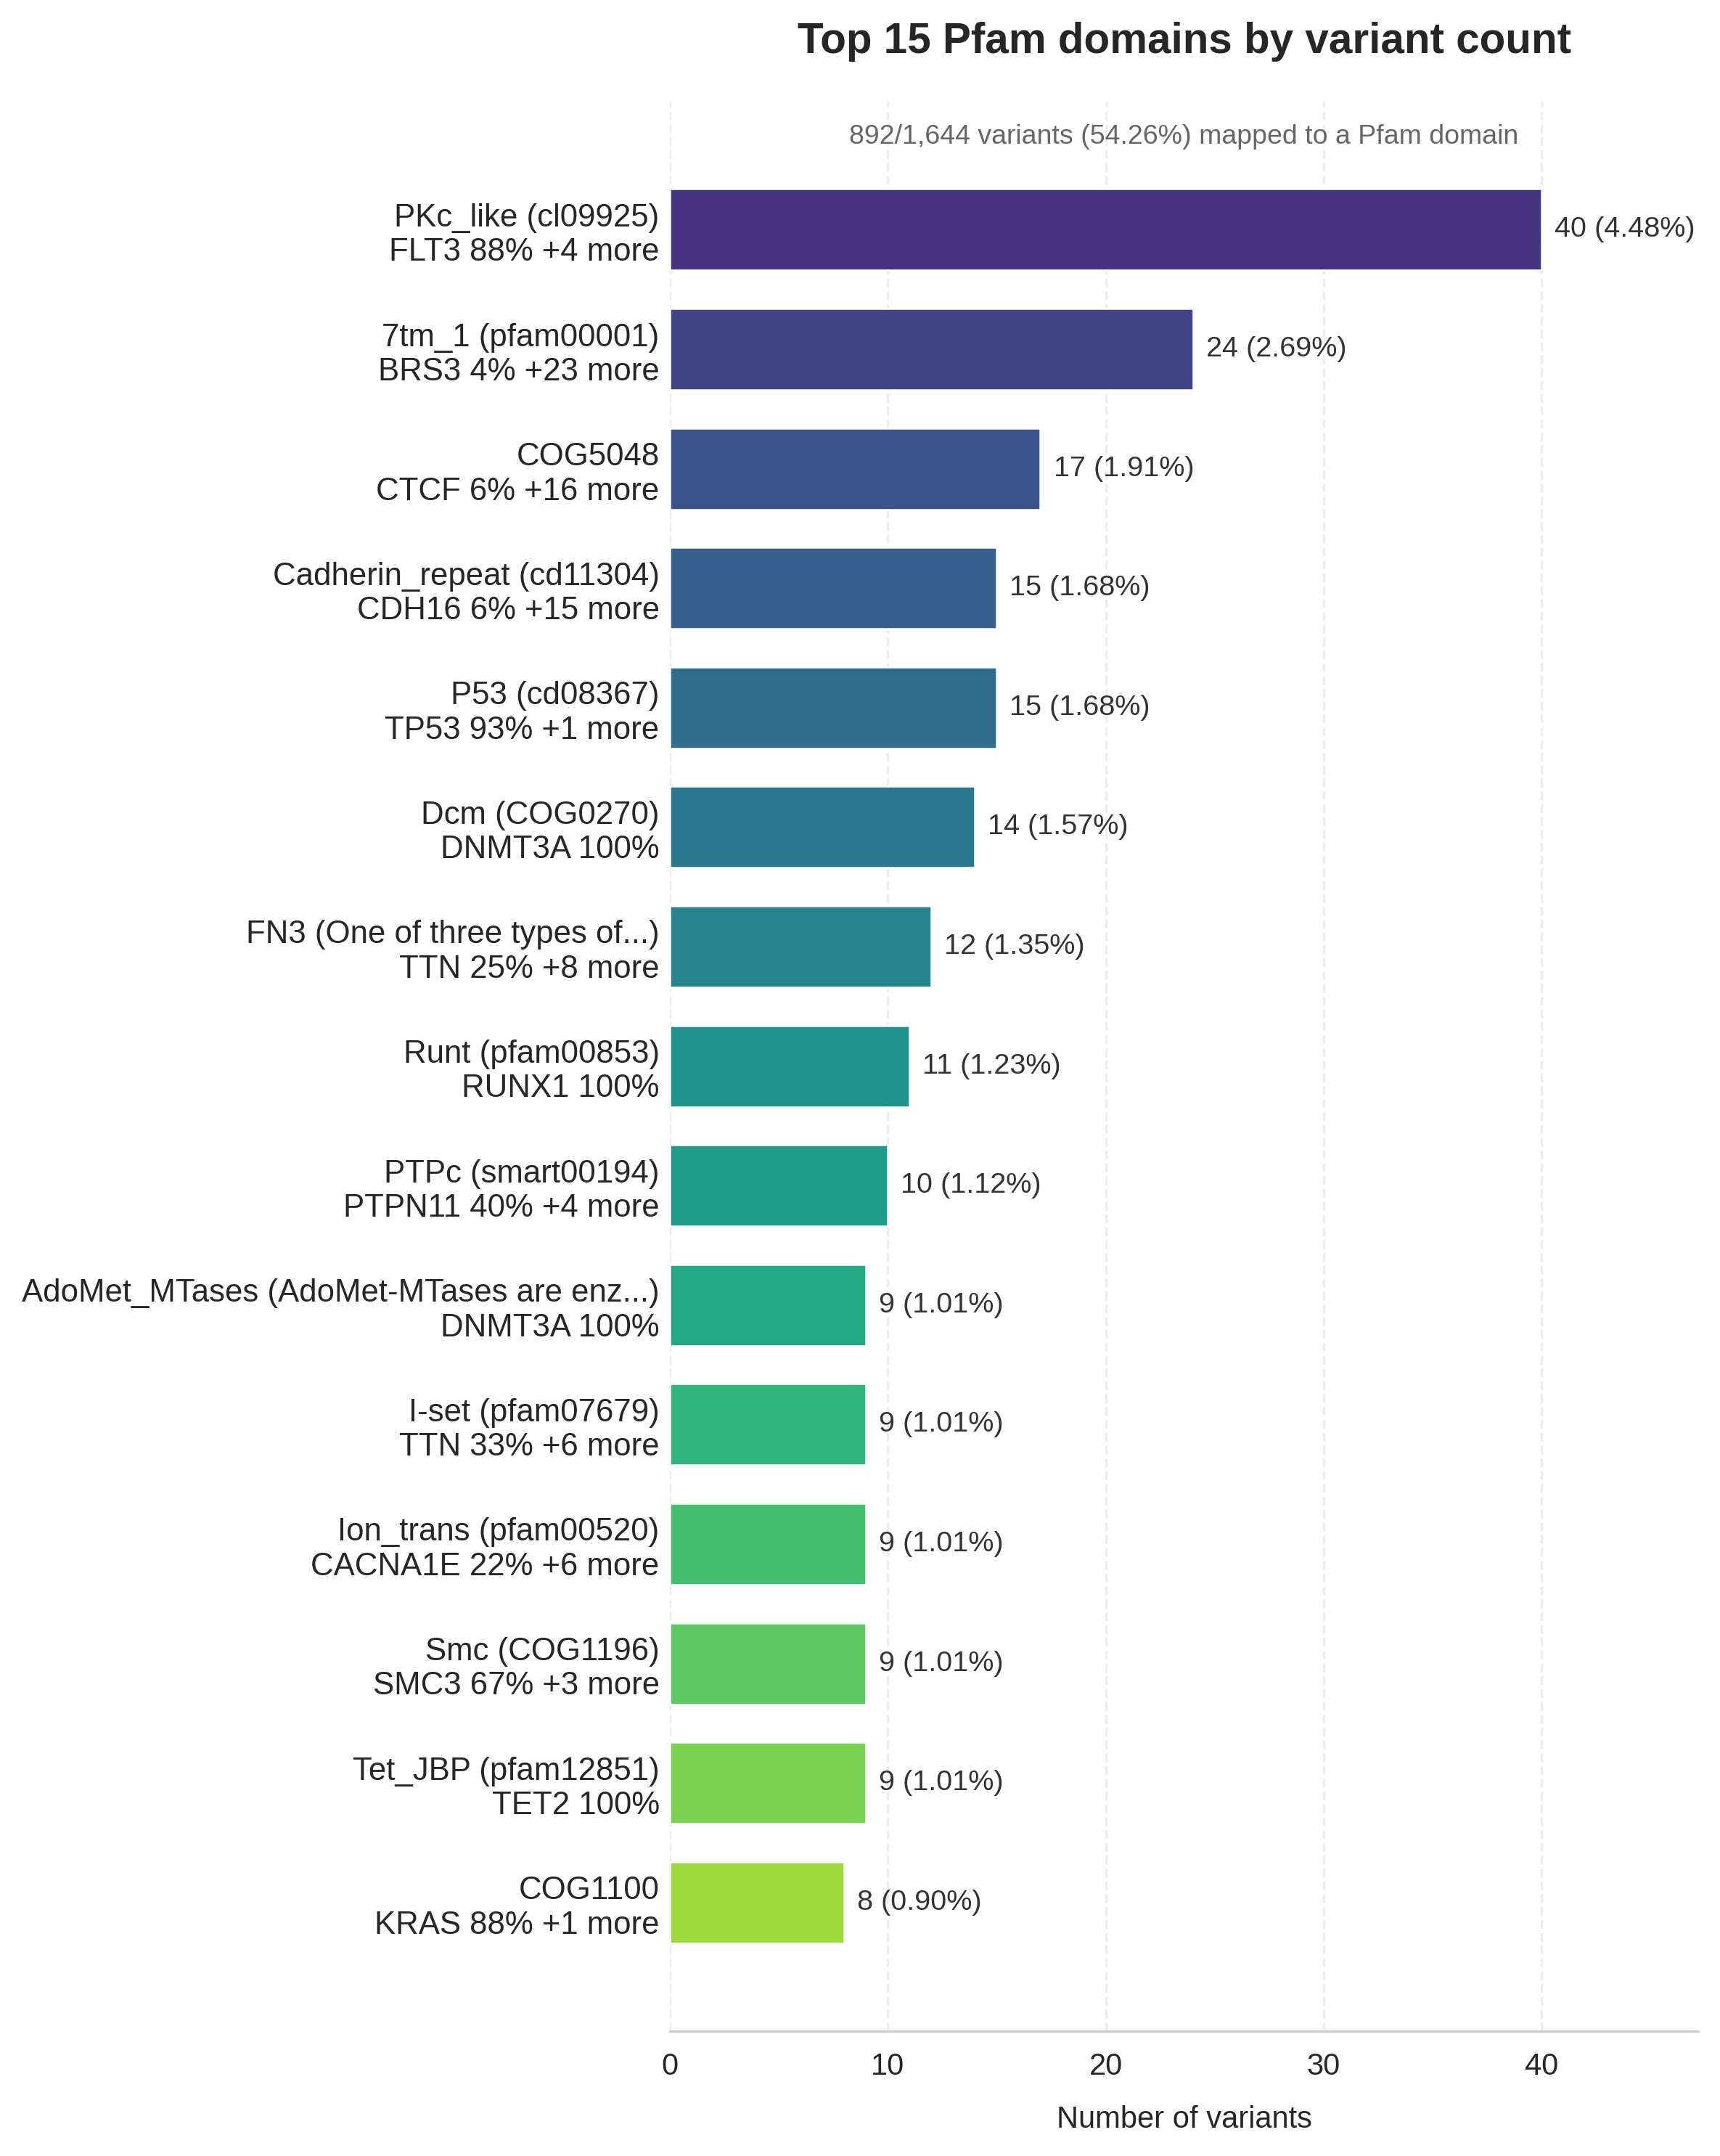

In [32]:
fig, ax = annotated_basic.plot_pfam_domains(
    top_n=15, 
    figsize=(8, 10)
)
fig.savefig(out("pfam_domains_basic.png"))

2026-09-23 16:41:17,359 | INFO | pyMut.analysis.pfam_annotation | Amino acid position column (from previous annotate_pfam): 'VEP_Protein_position'
2026-09-23 16:41:17,389 | INFO | pyMut.analysis.pfam_annotation | 1,428/1,644 variants (86.9%) mapped to a Pfam domain


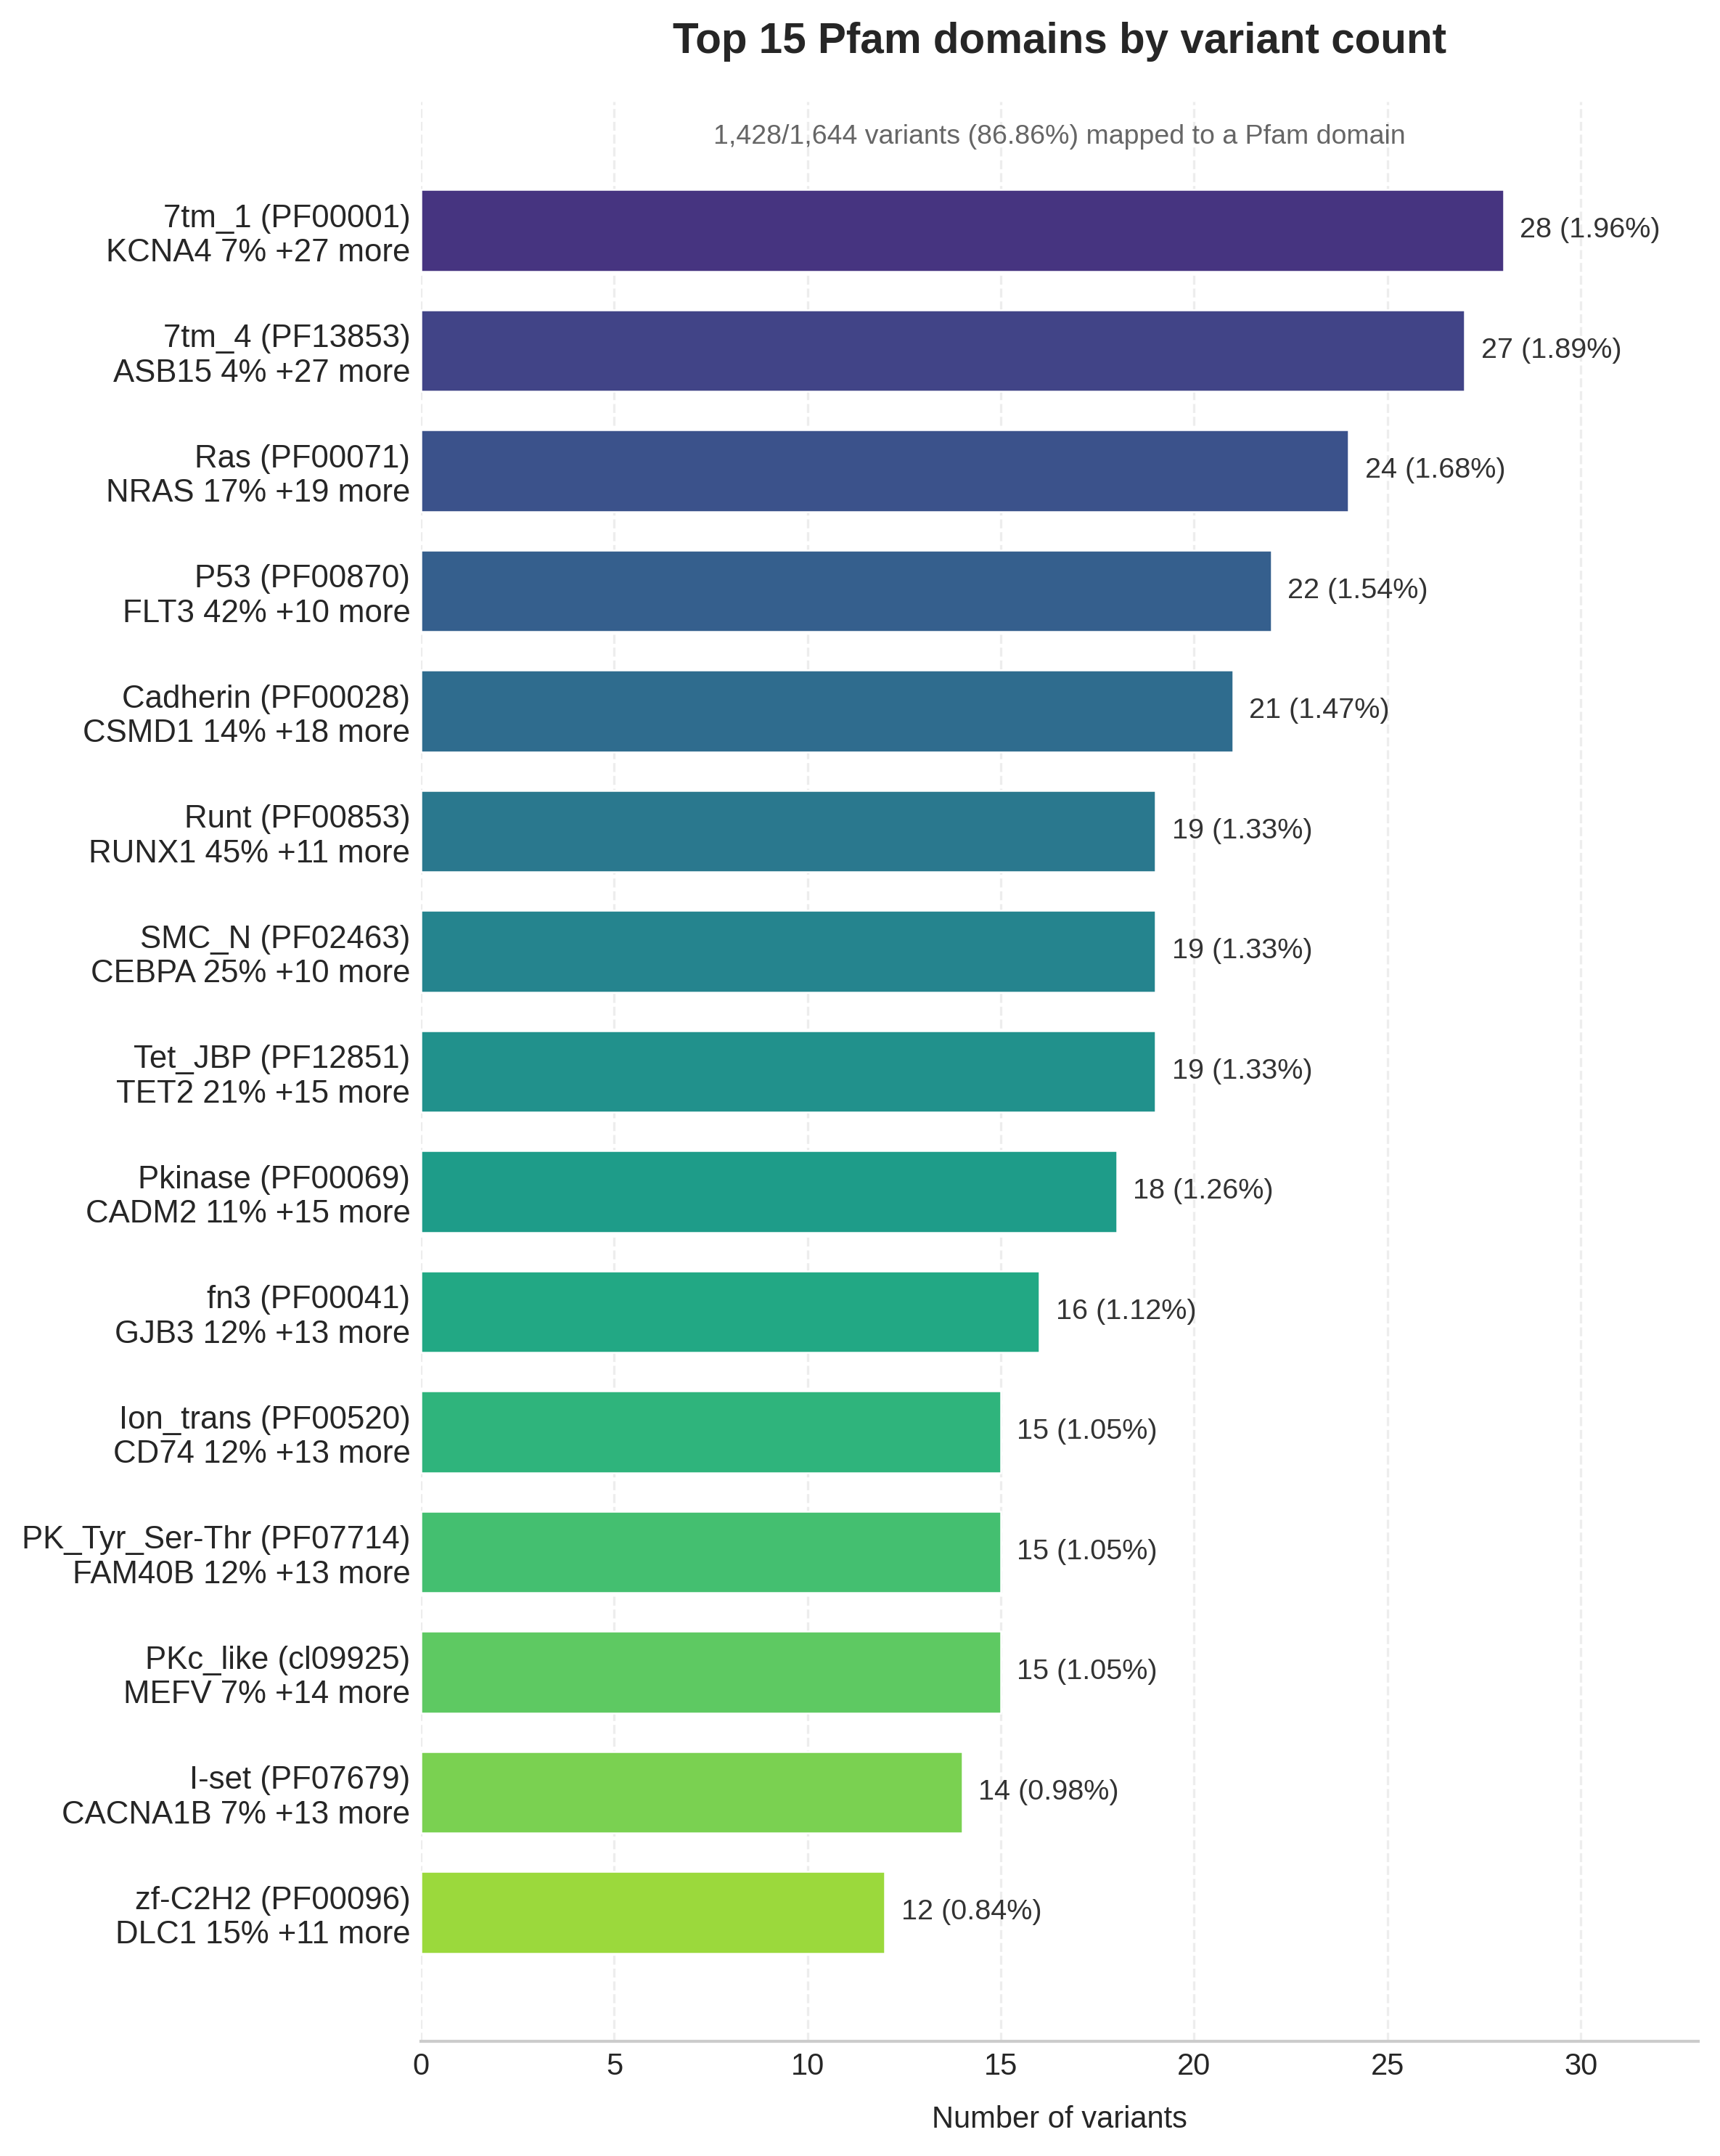

In [33]:
fig_extended, ax = annotated_extended.plot_pfam_domains(
    top_n=15, 
    figsize=(8, 10)
)
fig_extended.savefig(out("pfam_domains_extended.png"))

2026-09-23 16:41:19,167 | INFO | pyMut.analysis.pfam_annotation | Amino acid position column (from previous annotate_pfam): 'VEP_Protein_position'
2026-09-23 16:41:19,197 | INFO | pyMut.analysis.pfam_annotation | 892/1,644 variants (54.3%) mapped to a Pfam domain


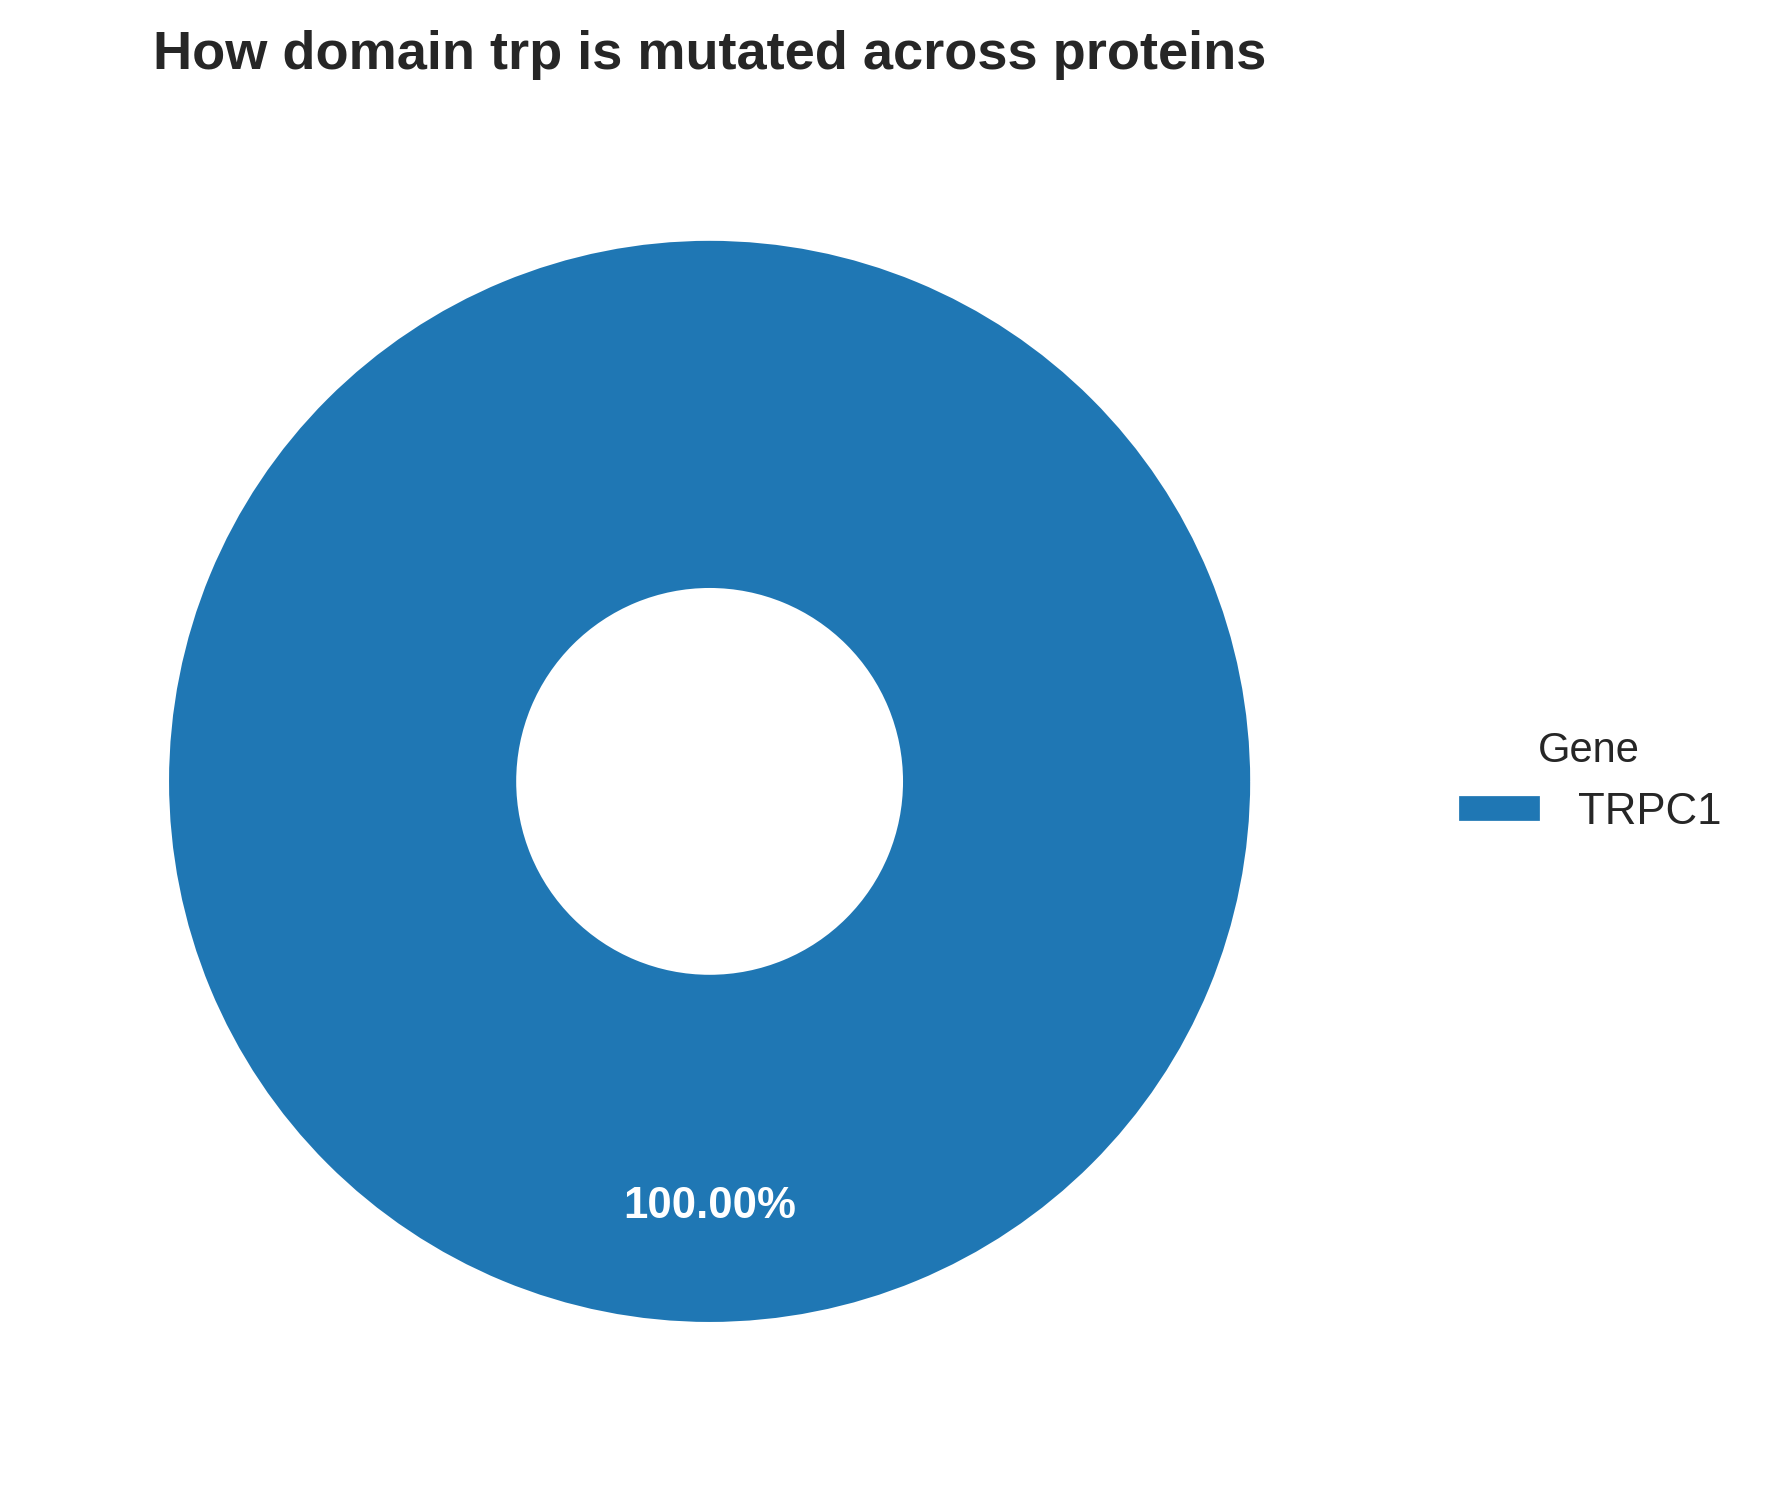

In [34]:
fig2, ax2 = annotated_basic.plot_pfam_domain_breakdown(
    'trp', kind='donut',base_fontsize=11, title_fontsize=13,
    figsize=(6,6), donut_width=0.65
)
fig2.savefig(out("pfam_domains_donutplot_basic.png"))

2026-09-23 16:41:19,923 | INFO | pyMut.analysis.pfam_annotation | Amino acid position column (from previous annotate_pfam): 'VEP_Protein_position'
2026-09-23 16:41:19,970 | INFO | pyMut.analysis.pfam_annotation | 1,428/1,644 variants (86.9%) mapped to a Pfam domain


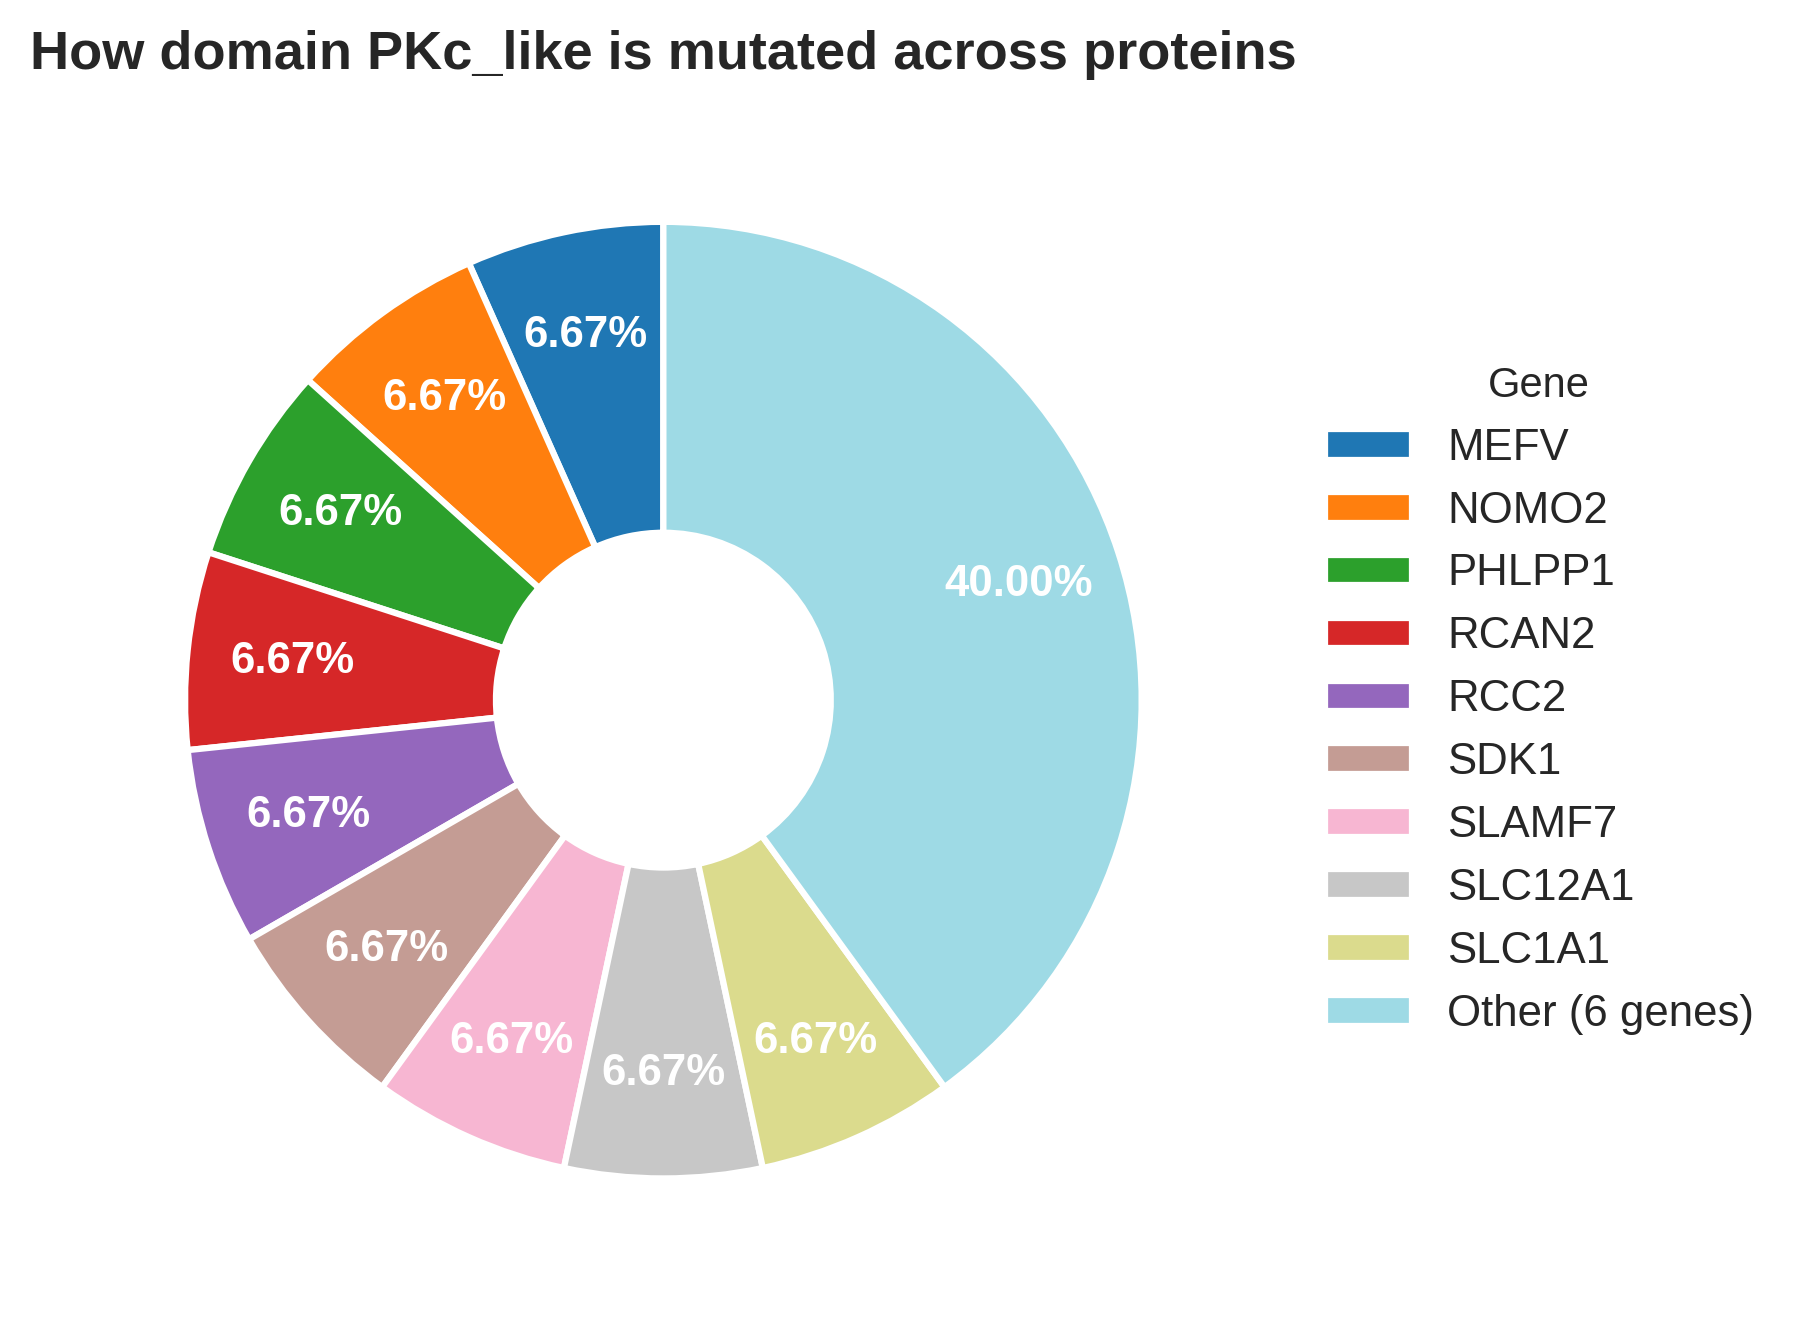

In [35]:
fig2_extended, ax2 = annotated_extended.plot_pfam_domain_breakdown(
    'PKc_like', kind='donut',base_fontsize=11, title_fontsize=13,
    figsize=(6,6), donut_width=0.65
)
fig2_extended.savefig(out("pfam_domains_donutplot_extended.png"))

2026-09-23 16:41:21,571 | INFO | pyMut.analysis.pfam_annotation | Amino acid position column (from previous annotate_pfam): 'VEP_Protein_position'
2026-09-23 16:41:21,622 | INFO | pyMut.analysis.pfam_annotation | 892/1,644 variants (54.3%) mapped to a Pfam domain


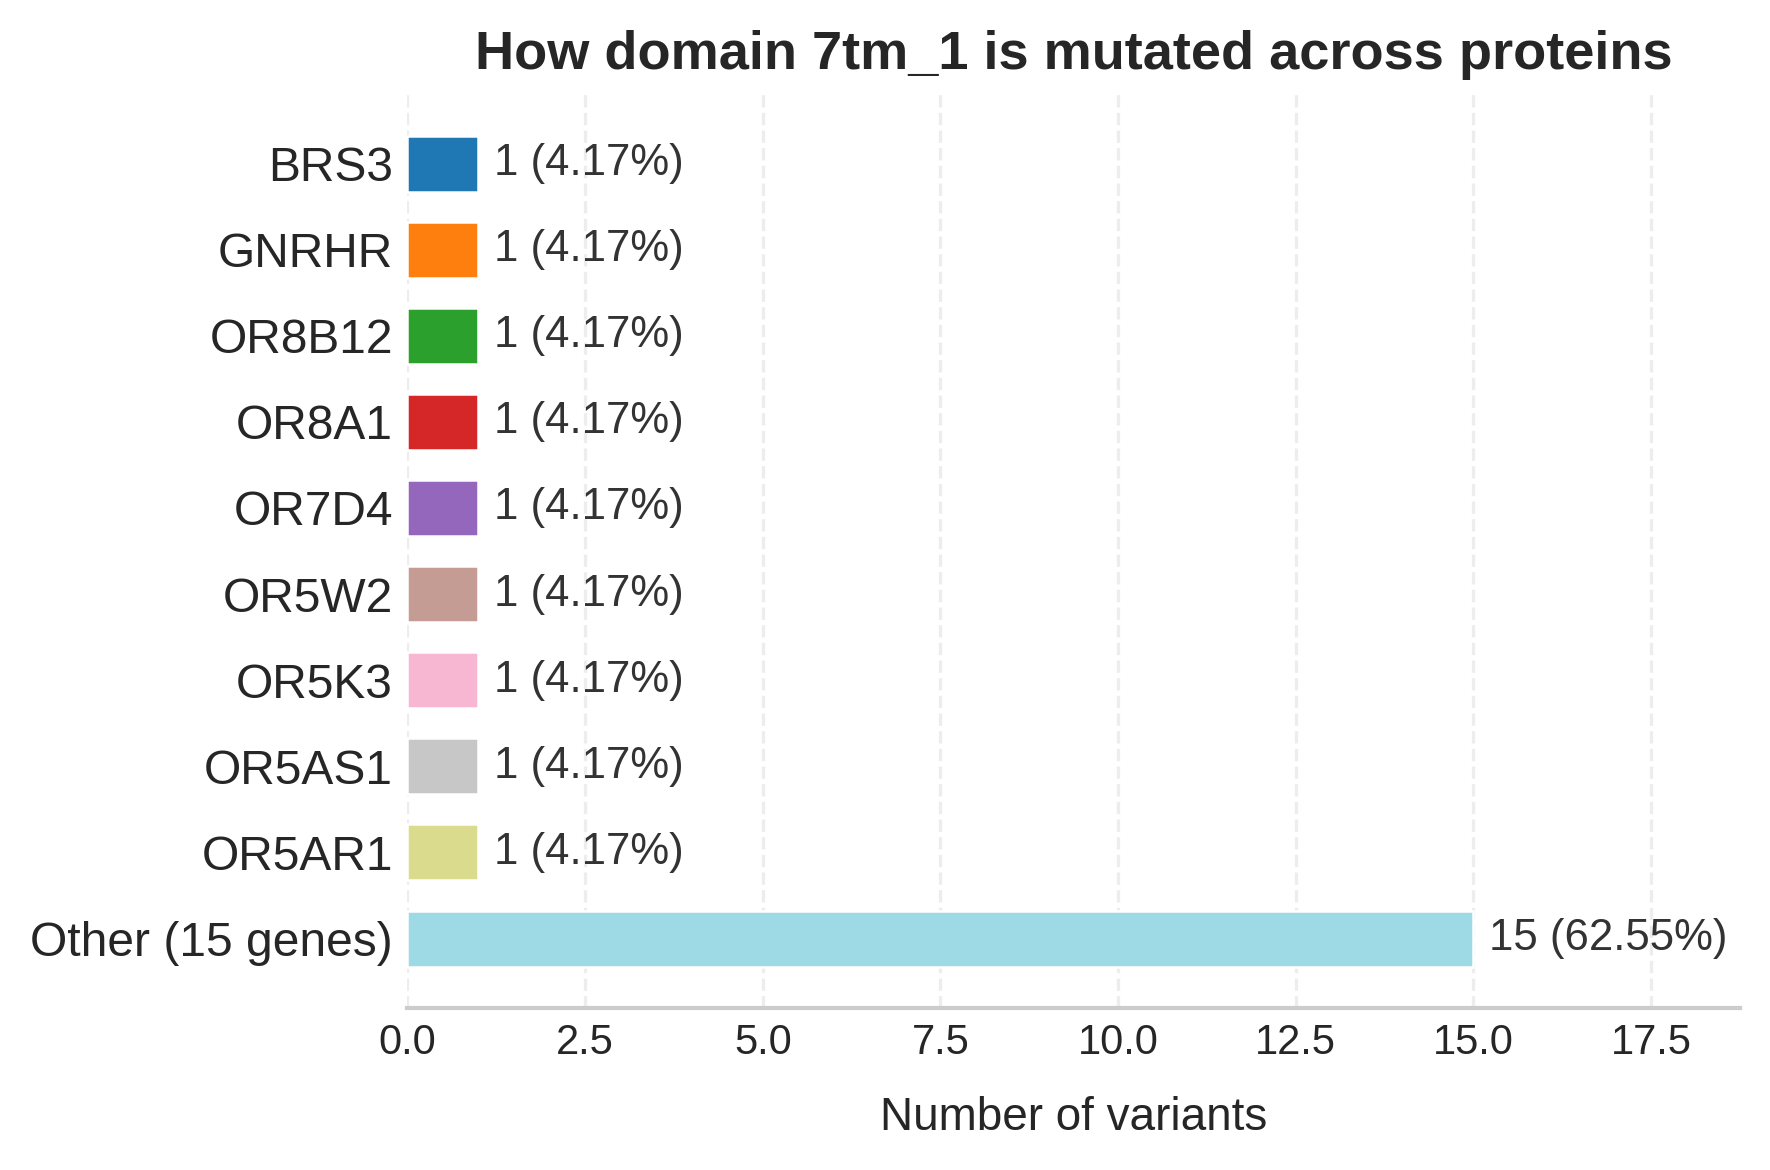

In [36]:
fig3, ax3 = annotated_basic.plot_pfam_domain_breakdown(
    '7tm_1', base_fontsize=11, title_fontsize=13,
    figsize=(6,4)
)
fig3.savefig(out("pfam_domains_proteins_barplot_basic.png"))

2026-09-23 16:41:22,725 | INFO | pyMut.analysis.pfam_annotation | Amino acid position column (from previous annotate_pfam): 'VEP_Protein_position'
2026-09-23 16:41:22,762 | INFO | pyMut.analysis.pfam_annotation | 1,428/1,644 variants (86.9%) mapped to a Pfam domain


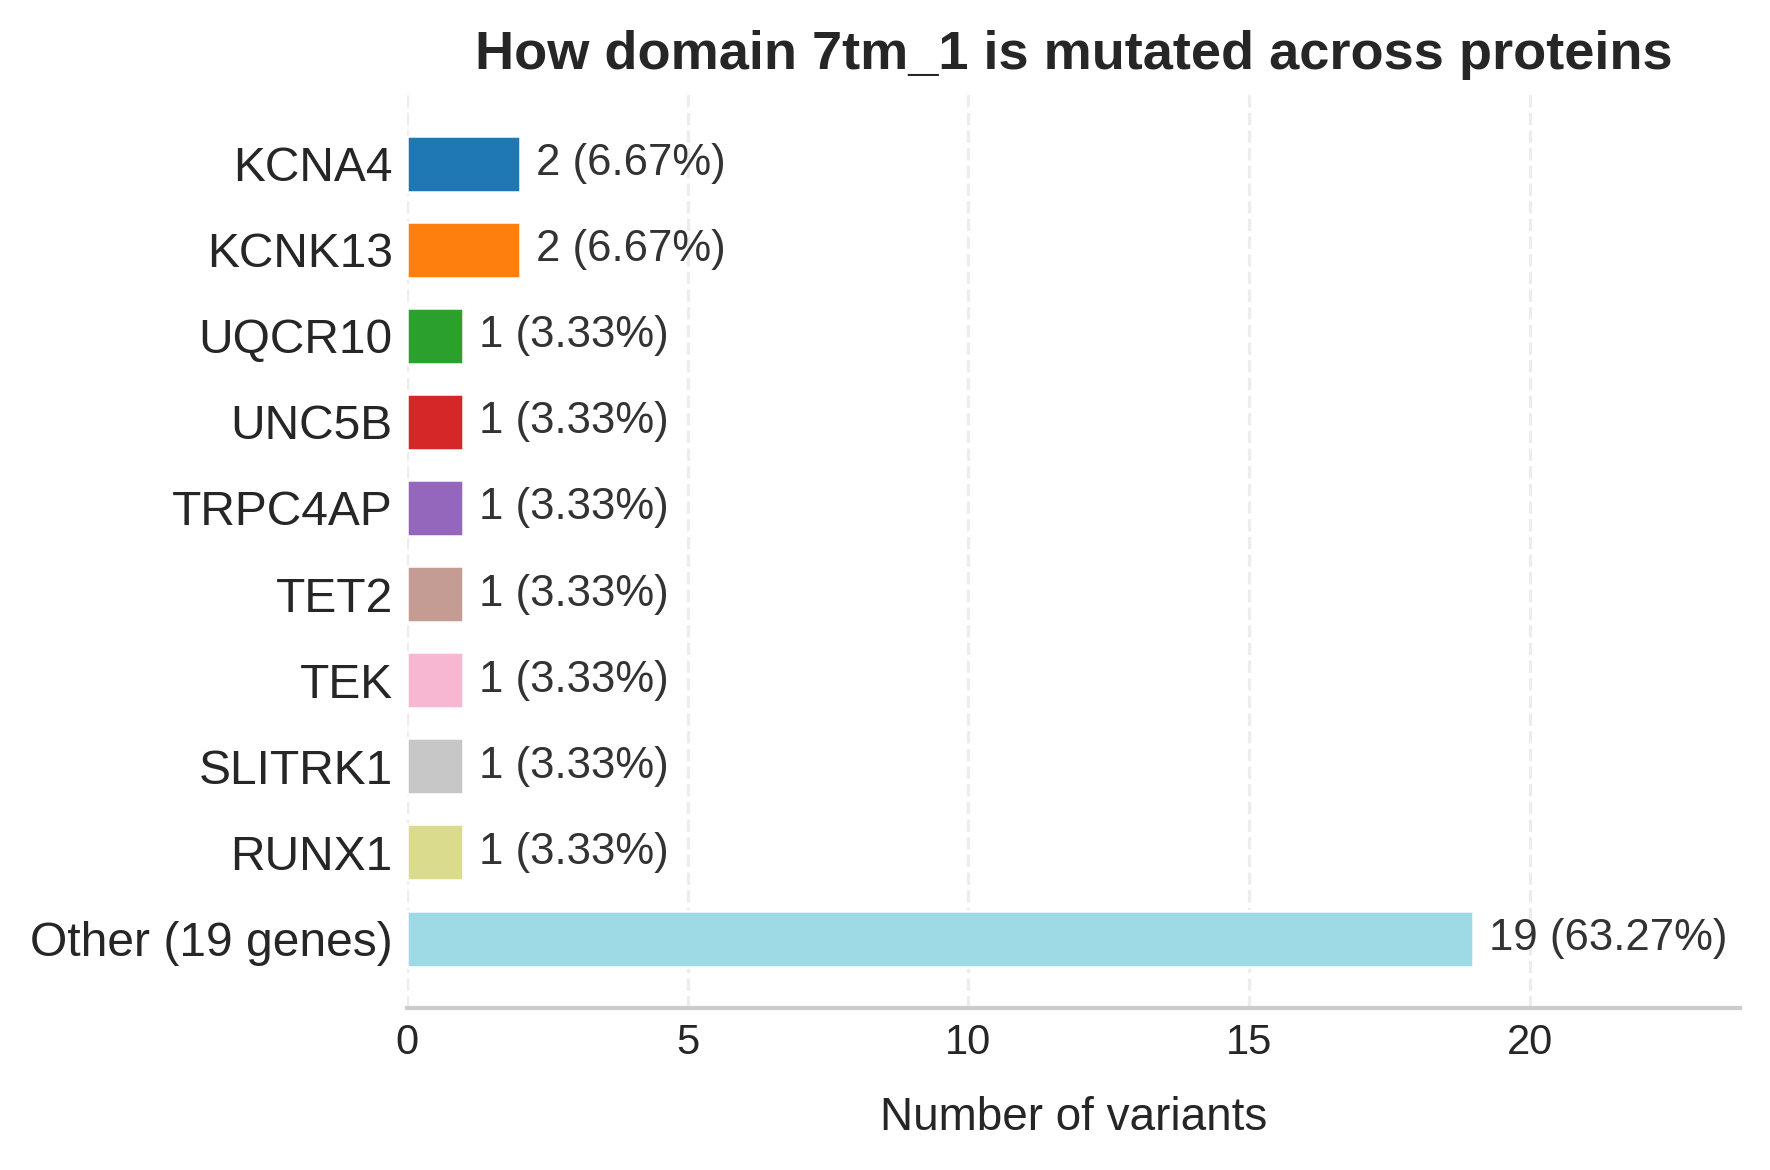

In [37]:
fig3_extended, ax3 = annotated_extended.plot_pfam_domain_breakdown(
    '7tm_1', base_fontsize=11, title_fontsize=13,
    figsize=(6,4)
)
fig3_extended.savefig(out("pfam_domains_proteins_barplot_extended.png"))